In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install flowio

In [3]:
import shutil
import pandas as pd
import random
import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging
import seaborn as sns
import os
import math

PYTHONHASHSEED = '42'
TF_DETERMINISTIC_OPS = '1'
TF_CUDNN_DETERMINISTIC = '1'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # For CuDNN ops

import glob
import json
import tensorflow as tf
import sys
import pickle
import time
import csv
import traceback
import gc

from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import fbeta_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve


In [4]:

fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

model_path = f'{cellcnn_path}Old_CellCNN/'
if model_path not in sys.path:
    sys.path.append(model_path)

save_path = f'{cellcnn_path}results/'
if save_path not in sys.path:
    sys.path.append(save_path)

modules_dir = f'{cellcnn_path}modules/'
if modules_dir not in sys.path:
    sys.path.append(modules_dir)

In [5]:
decache_files = ['timepoints_elaboration', 'model_grid', 'run_models', 'new_datasets_generation',
                'training', 'utils', 'cv_folds', 'classification', 'plotting']

# Remove from cache
from utils import remove_from_cache
remove_from_cache(decache_files)

from model_grid import CellCnn

from timepoints_elaboration import load_data, donation_extraction
from run_models import  trials_train_CellCNN_old, trials_test_CellCNN_old
from new_datasets_generation import splitting_and_dataset_elaboration

from training import run_training, val_res_pred, train_val_finalizing, test_res_pred, find_theta_best
from utils import flatten, remove_labels, retrieve_labels, show_blast_distribution_perc
from utils import prepare_results_to_save, subset_sampling, generate_seeds
from utils import nsub_ncells_comb, save_models, load_models
from cv_folds import generate_LOPOCV_dicts, generate_LOPOCV_folds, extract_fold_features
from classification import find_robust_threshold





timepoints_elaboration not found in cache
model_grid not found in cache
run_models not found in cache
new_datasets_generation not found in cache
training not found in cache
utils removed from cache
cv_folds not found in cache
classification not found in cache
plotting not found in cache


In [6]:

tuning_exp = 'Trial_4_NO_AS_bayesian_tuning'


config_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'
os.makedirs(config_save_dir, exist_ok=True)

with open(os.path.join(config_save_dir, 'config.pkl'), 'rb') as f:
            config = pickle.load(f)

starting_seed = config['starting_seed']


print(starting_seed)

filters_plot_exp = 'filter_resp_plots'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{filters_plot_exp}/'
os.makedirs(config_save_dir, exist_ok = True)

plotdir = os.path.join(config_save_dir, 'plots')
os.makedirs(plotdir, exist_ok = True)

exp = 'Trial_4_NO_AS_Ensemble'

1000


In [7]:
%%time

data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)#, max_file = 15 )#, remove_control = True)



Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
Elaborating file 8: /content/drive/MyDrive/0.

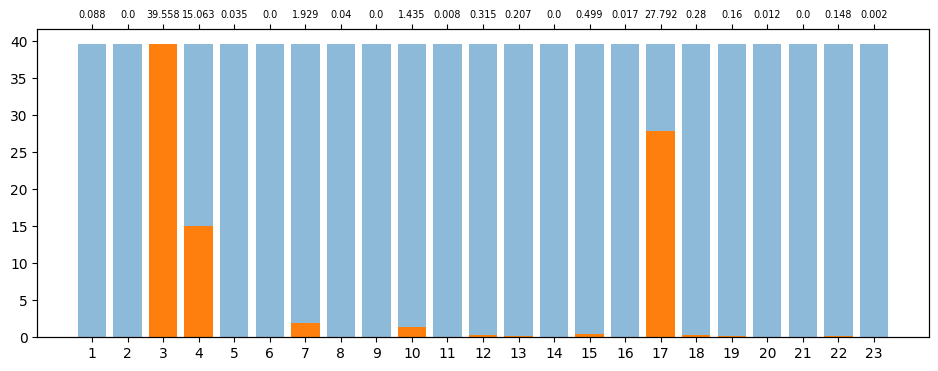

[np.float64(0.088), np.float64(0.0), np.float64(39.558), np.float64(15.063), np.float64(0.035), np.float64(0.0), np.float64(1.929), np.float64(0.04), np.float64(0.0), np.float64(1.435), np.float64(0.008), np.float64(0.315), np.float64(0.207), np.float64(0.0), np.float64(0.499), np.float64(0.017), np.float64(27.792), np.float64(0.28), np.float64(0.16), np.float64(0.012), np.float64(0.0), np.float64(0.148), np.float64(0.002)]


In [8]:

tot_perc_list = show_blast_distribution_perc(ALL_DATASETS, multiple_donations, return_perc = True, decimals = 3)
print(tot_perc_list)

In [9]:

full_LOPOCV_dicts = generate_LOPOCV_dicts(multiple_donations, ALL_DATASETS)
LOPOCV_patients_folds = generate_LOPOCV_folds(full_LOPOCV_dicts, ALL_DATASETS, starting_seed)

dict_keys(['2', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['1']) [np.float64(0.08762), np.float64(0.0)]
dict_keys(['1', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['2']) [np.float64(39.55814), np.float64(15.0633)]
dict_keys(['1', '2', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['3']) [np.float64(0.03462), np.float64(0.0)]
dict_keys(['1', '2', '3', '6', '7', '8', '9', '11', '12']) dict_keys(['4']) [np.float64(1.92897), np.float64(0.04035), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '7', '8', '9', '11', '12']) dict_keys(['6']) [np.float64(1.43503), np.float64(0.00775)]
dict_keys(['1', '2', '3', '4', '6', '8', '9', '11', '12']) dict_keys(['7']) [np.float64(0.31479), np.float64(0.20732), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '6', '7', '9', '11', '12']) dict_keys(['8']) [np.float64(0.49896), np.float64(0.01692)]
dict_keys(['1', '2', '3', '4', '6', '7', '8', '11', '12']) dict_keys(['9']) [np.float64(27.7918), np.float64(0.2798)]
dict_keys(['1', '2', '

In [10]:
from pathlib import Path
def load_training_models(model_cvfolds_dir ):
    """Loads all cross-validation models using safe path resolution."""
    all_trials = os.listdir(model_cvfolds_dir)

    cross_val_models_list = []
    for t, trial in enumerate(all_trials): # cross validation folds

        seeds_dir = f'{model_cvfolds_dir}/inner_fold_{t}/models'
        all_seeds = os.listdir(seeds_dir)

        loaded_models_lists = []
        for s in range(len(all_seeds)):

            model_dir = f'{seeds_dir}/seed_{s}/'

            with open(os.path.join(model_dir, 'metadata.pkl'), 'rb') as f:
                meta = pickle.load(f)

            model = load_models(CellCnn, meta)
            loaded_models_lists.append(model)
        cross_val_models_list.append(loaded_models_lists)
    return cross_val_models_list


def keras_param_vector(params):
    """Extracts weights from a model"""

    W = np.squeeze(params[0])
    b = params[1]
    W_out = params[2]
    # store the (convolutional weights + biases + output weights) per filter

    W_tot = np.hstack([W.T, b.reshape(-1, 1), W_out])
    return W_tot

def get_full_network_prob(params, data, scaler=None):
    """Calculates network probabilities for given data."""
    if scaler is not None:
        data = scaler.transform(data)

    W = np.squeeze(params[0])
    b = params[1]
    W_out = params[2]
    # store the (convolutional weights + biases + output weights) per filter
    b_out = params[3] if len(params) > 3 else 0.0

    hidden_z = np.dot(data, W) + b
    hidden_a = relu(hidden_z)  # Attivazione ReLU

    logits = np.dot(hidden_a, W_out) + b_out
    probs = 1 / (1 + np.exp(-logits))
    positive_probs = probs[:, 1]
    return np.hstack([positive_probs])


def get_selected_cells(filter_w, data, scaler=None, filter_response_thres=0,
                       export_continuous=False):
    """Calculates cell responses based on a specific filter's weights."""

    nmark = data.shape[1]
    if scaler is not None:
        data = scaler.transform(data)

    w, b = filter_w[:nmark], filter_w[nmark]

    g = np.dot(data, w) + b

    if export_continuous:
        g = relu(g).reshape(-1, 1)
        g_thres = (g > filter_response_thres).reshape(-1, 1)
        return np.hstack([g, g_thres])
    else:
        return (g > filter_response_thres).astype(int)


def get_cells_prob(filter_w, data, scaler=None, filter_response_thres=0):
    """Retrieves continuous ReLU-activated probabilities for cells."""

    nmark = data.shape[1]
    if scaler is not None:
        data = scaler.transform(data)

    w, b = filter_w[:nmark], filter_w[nmark]
    g = np.dot(data, w) + b
    g = relu(g).reshape(-1, 1)

    return np.hstack([g])


def relu(x):
    return x * (x > 0)

def retrieve_flags(x, fold_loaded_models_lists):
    """Computes mean probabilities across an ensemble of models."""

    print('=========== Computing Probabilities ==============')
    all_probs_list =  []
    for model in fold_loaded_models_lists: # several seeds (our case 1 seed only)

        for net in model.results['best_3_nets']:

            all_probs = get_full_network_prob(net, x,  model.results['scaler'])
            all_probs_list.append(all_probs)

    all_probs_mean = np.mean(all_probs_list, axis = 0).reshape(-1, 1)
    print(all_probs_mean)

    df = pd.DataFrame(all_probs_mean)

    return df



def check_detected_cells(comprehensive_df, thr, metrics_list = None, function_list = None):
    """Evaluates the predictions against true labels using given metrics."""

    print('Total number of cells:', len(comprehensive_df))
    print('Total number of cancer cells:', len(comprehensive_df[comprehensive_df['IsBlast'] == 1]))
    print('Percentage of cancer cells:', round(100*len(comprehensive_df[comprehensive_df['IsBlast'] == 1]) / len(comprehensive_df),4), '%' )
    print('Adopted Threshold:', thr)

    true_labels = comprehensive_df['IsBlast'].to_numpy()
    act_cells_values = comprehensive_df.iloc[:,0]


    print('True Labels Count', len(comprehensive_df[comprehensive_df['IsBlast'] == 1]))

    if metrics_list is None:
        metrics_list = ['F1-score', 'Recall', 'Precision', 'Accuracy']

    if function_list is None:
        from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
        function_list = [f1_score, recall_score, precision_score, accuracy_score]

    pred_labels = (act_cells_values > thr).astype(int)
    print('Pred Labels Count', np.sum(pred_labels))

    for met, func in zip(metrics_list, function_list):
        met_score = func(true_labels, pred_labels)
        print(f'{met}: { met_score*100:.2f}%')



def get_filter_prob(filter_weights, data, scaler=None):

    """Calculates probabilities for a given filter using a sigmoid activation."""
    if scaler is not None:
        data = scaler.transform(data)

    hidden_z = np.dot(data, filter_weights)

    probs = 1 / (1 + np.exp(-hidden_z))

    positive_probs = probs[:, 0] if probs.ndim > 1 else probs.ravel()
    return positive_probs

def extract_filters_from_net(net):
    """Extracts and transposes filters from the network architecture."""
    return net[0].transpose()

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

def cluster_filters(all_best_filters, show_plot = True):
    """Clusters filters based on cosine similarity and plots a dendrogram."""
    print('=========== Clustering Filters ==============')

    correlations = cosine_similarity(np.array(all_best_filters))
    dissimilarity = 1 - abs(correlations)
    np.fill_diagonal(dissimilarity, 0)

    Z = linkage(squareform(dissimilarity), 'complete')

    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        dendrogram(Z, orientation='top', leaf_rotation=90)
        plt.title("Filter Clustering Dendrogram")
        display(fig)
        plt.close(fig)

    return Z

import numpy as np
from scipy.cluster.hierarchy import fcluster

def select_relevant_filters(all_best_filters, all_best_scalers, filter_f1_list, best_thr_list, distance_threshold, filter_selection_thr = 0.6, one_per_model = False):
    """Selects the best performing filter from each hierarchical cluster."""
    Z = cluster_filters(all_best_filters)

    # Cut the dendrogram at the provided threshold
    cluster_labels = fcluster(Z, t=distance_threshold, criterion='distance')

    sample_filters = []
    unique_clusters = np.unique(cluster_labels)

    for id_cluster in unique_clusters:

        indici_nel_cluster = np.where(cluster_labels == id_cluster)[0]
        f1_del_cluster = [filter_f1_list[i] for i in indici_nel_cluster]
        best_idx = indici_nel_cluster[np.argmax(f1_del_cluster)]

        sample_filters.append(best_idx)

    # Convert lists to arrays for vectorized indexing
    best_f1_from_clusters =  np.array(filter_f1_list)[sample_filters]
    best_filters_from_clusters =  np.array(all_best_filters)[sample_filters]
    best_scalers_from_clusters = np.array(all_best_scalers)[sample_filters]
    best_thr_from_clusters =  np.array(best_thr_list)[sample_filters]

    # Filter based on the F1 performance threshold (filter_selection_thr)
    choising_condition = best_f1_from_clusters > filter_selection_thr

    selected_filters = best_filters_from_clusters[choising_condition]
    selected_filters = [np.array(filter) for filter in selected_filters]

    selected_scalers = best_scalers_from_clusters[choising_condition].tolist()

    # Create a backup of the absolute best filter overall, in case none passed the threshold
    best_f1_idx = np.argmax(best_f1_from_clusters)
    best_filter = best_filters_from_clusters[best_f1_idx]
    best_scaler = best_scalers_from_clusters[best_f1_idx]

    filter_backup = [best_f1_from_clusters[best_f1_idx], best_filter, best_scaler]

    # Fallback logic if no filters met the threshold
    if len(selected_filters) == 0 and one_per_model:
        print(f'No filter scored F1 > {filter_selection_thr}. Selected the best one (F1 = {filter_backup[0]:.4f})')
        selected_filters = [best_filter]
        selected_scalers = [best_scaler]

    return selected_filters, selected_scalers, filter_backup



def extract_filter_from_backup(selected_backups_across_folds, selected_filters_across_folds, selected_scalers_across_folds):
    """Finds the best performing filter across all backups if none were selected naturally."""
    max_backup_f1 = 0
    print('no filters selected. Extract the best one in the backup')

    for cv_b, cv_backups in enumerate(selected_backups_across_folds):
        for m_b, model_backups in enumerate(cv_backups):

            f1, filter, scaler = model_backups
            if f1 > max_backup_f1:
                max_backup_f1 = f1
                best_filter = filter
                best_scaler = scaler
                best_cv = cv_b
                best_model = m_b

    selected_filters_across_folds[best_cv][best_model] = [best_filter]
    selected_scalers_across_folds[best_cv][best_model] = [best_scaler]
    return selected_filters_across_folds, selected_scalers_across_folds


def get_best_thr(true_cells_labels, pred_probs, show = False):
    """Calculates the optimal threshold that maximizes the F1-score."""

    print('=========== Finding Best Threshold ==============')

    prec, rec, thr = precision_recall_curve(true_cells_labels, pred_probs)

    # Calculate F1 score for all thresholds
    f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
    best_idx = np.argmax(f1_curve[:-1])
    best_thr = thr[best_idx]
    max_f1 = f1_curve[:-1][best_idx]

    print(f'F1-score: { max_f1*100:.2f}%')

    if show:
        show_f1_curve(thr, f1_curve[:-1])
    return  best_thr, max_f1

def retrieve_filters_scalers(fold_loaded_models_lists):
    """Retrieves all filters and their corresponding scalers from model results."""
    all_best_filters = []
    all_scalers = []
    for m, model in enumerate(fold_loaded_models_lists): # several seeds (our case 1 seed only)

        model_scalers_list = []
        model_filters_list = []

        for net in model.results['best_3_nets']: # enter in the model results

            filters = extract_filters_from_net(net)

            for filt in filters:
                model_filters_list.append(filt.squeeze())  # save each filter
                model_scalers_list.append(model.results['scaler'])

        all_best_filters.append(model_filters_list)
        all_scalers.append(model_scalers_list)


    return all_best_filters, all_scalers

def show_f1_curve(thresholds: np.ndarray, f1_scores: np.ndarray):
    """Plots the F1 score against varying thresholds (Fixes the previous plotting bug)."""
    fig = plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1_scores, color='blue', linewidth=2)

    plt.xlabel("Probability Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs. Probability Threshold")
    plt.grid(True, linestyle='--', alpha=0.7)

    display(fig)
    plt.close(fig)




def metadata_extract_filter_from_backup(filter_metadata_df):
    """Extracts the best performing filter from backups across all folds."""
    cv_folds = set(filter_metadata_df['cv_fold'].to_list())

    max_backup_f1 = -1
    print('no filters selected. Extract the best one in the backup')

    for cv_b in range(len(cv_folds)):
        cv_backups = filter_metadata_df[filter_metadata_df['cv_fold'] == cv_b]['backup']

        for m_b, model_backups in enumerate(cv_backups):
            f1, filter, scaler = model_backups

            if f1 > max_backup_f1:
                max_backup_f1 = f1

                best_filter = [filter]
                best_scaler = [scaler]
                best_cv = cv_b
                best_model = m_b
                best_model_backup = model_backups

    return best_filter, best_scaler, best_cv, best_model, best_model_backup

def apply_backup_if_needed(filter_metadata_df):
    """Checks if any filters were selected; if not, forcefully applies the best backup."""
    filter_presence = any(len(f) > 0 for f in filter_metadata_df['filter_weights']) # checks the presence of any non empty list

    if not filter_presence:
        best_filter, best_scaler, best_cv, best_model, best_model_backup = metadata_extract_filter_from_backup(filter_metadata_df)

        # set condition we are looking for, so specific cv_fold and specific model_ID
        mask = (filter_metadata_df['cv_fold'] == best_cv) & (filter_metadata_df['model_ID'] == best_model)

        target_row_idx = filter_metadata_df[mask].index[0] #index returns a list of indixes. in our case, given cv eand model id , it is unique

        filter_metadata_df.at[target_row_idx, 'filter_weights'] = best_filter
        filter_metadata_df.at[target_row_idx, 'scaler'] = best_scaler

    return filter_metadata_df


def evaluate_single_filter(comprehensive_val_df, true_cells_labels, model_filters, model_scalers):
    """Evaluates individual filter from an initialization seed and returns their max F1 and best threshold."""
    model_max_f1 = []
    model_best_thr = []

    # contains several filters from the same seed (filters from the best 3 nets are have been concatewnated in a single list)
    for f, (filter, scaler) in enumerate(zip(model_filters, model_scalers)):
        print('Analyzing filter:', f)

        pred_probs = get_filter_prob(filter, comprehensive_val_df, scaler=scaler)
        best_thr, max_f1  = get_best_thr(true_cells_labels, pred_probs)
        print(f'F1-score: { max_f1*100:.2f}%')

        model_max_f1.append(max_f1)
        model_best_thr.append(best_thr)

    return model_best_thr, model_max_f1


def extract_data_from_fold(val_pat, multiple_donations, ALL_DATASETS):
    """Extracts, formats, and separates labels from the validation fold data."""

    val_datasets_extracted = donation_extraction(val_pat, multiple_donations, ALL_DATASETS)
    val_datasets_extracted_flat_with_labels, _ = retrieve_labels(val_datasets_extracted, remove = False, flat = True)

    comprehensive_val_df = pd.concat(val_datasets_extracted_flat_with_labels, ignore_index = True) # concatenate all df within the list

    del val_datasets_extracted_flat_with_labels
    gc.collect()

    true_cells_labels = comprehensive_val_df['IsBlast'].to_numpy()
    comprehensive_val_df.drop(columns=['IsBlast'], inplace=True)

    return comprehensive_val_df, true_cells_labels

def evaluate_folds_filters(train_kfolds, cv, multiple_donations, ALL_DATASETS, fold_loaded_models_lists, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD):
    """Pipeline to evaluate filters for a specific fold and select the best ones."""

    _, val_pat = train_kfolds[cv]
    comprehensive_val_df, true_cells_labels = extract_data_from_fold(val_pat, multiple_donations, ALL_DATASETS)
    all_best_filters, all_scalers = retrieve_filters_scalers(fold_loaded_models_lists) # seed/net/filter

    filters_metadata = []
    selected_filters_metadata = []

    for m, (model_filters, model_scalers) in enumerate(zip(all_best_filters, all_scalers)): # for each seed

        model_best_thr, model_max_f1 = evaluate_single_filter(comprehensive_val_df, true_cells_labels, model_filters, model_scalers)

        filters_metadata.append({
            'lopo_fold': LOPOCV_fold_idx,
            'cv_fold': cv,
            'model_ID': m,
            'filters': model_filters,
            'scalers': model_scalers,
            'best_thr': model_best_thr,
            'max_f1': model_max_f1
        })

        selected_filters, selected_scalers, filter_backup = select_relevant_filters(model_filters, model_scalers, model_max_f1, model_best_thr,
                                                                                        DIST_THRESHOLD, filter_selection_thr = FILTER_SEL_THRESHOLD, one_per_model=False)

        selected_filters_metadata.append({ 'lopo_fold': LOPOCV_fold_idx,
                                          'cv_fold': cv,
                                          'model_ID': m,
                                          'filter_weights': selected_filters,
                                          'scaler': selected_scalers,
                                          'backup': filter_backup
                                      })

    return selected_filters_metadata, filters_metadata

def filters_selection_phase(cross_val_models_list, train_kfolds, multiple_donations, ALL_DATASETS, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD):
    """Orchestrates filter selection across all cross-validation folds."""
    all_selected_filters_metadata = []
    all_filters_metadata = []

    for cv, fold_loaded_models_lists in enumerate(cross_val_models_list): # cross validation fold
        print(f'=========== Analysing Fold {cv} ==============')
        selected_filters_metadata, filters_metadata = evaluate_folds_filters(train_kfolds, cv, multiple_donations, ALL_DATASETS,
                                                                                 fold_loaded_models_lists, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD)

        all_selected_filters_metadata += selected_filters_metadata
        all_filters_metadata += filters_metadata

    filter_metadata_df = apply_backup_if_needed(pd.DataFrame(all_selected_filters_metadata))
    return filter_metadata_df, pd.DataFrame(all_filters_metadata)


def compute_mean_cells_probs(selected_filters, selected_scalers, comprehensive_val_df, compute_mean = True):
    """Calculates predictions across multiple filters. Averaged if compute_mean is True."""

    filters_flat = flatten(selected_filters)
    scalers_flat = flatten(selected_scalers)

    if not filters_flat:
        return np.array([])

    val_all_cells = []
    for filter, scaler in zip(filters_flat, scalers_flat):
        pred_probs = get_filter_prob(filter, comprehensive_val_df, scaler=scaler)
        val_all_cells.append(pred_probs)

    del comprehensive_val_df
    gc.collect()

    if compute_mean == True:
        return np.mean(val_all_cells, axis=0).ravel()

    return val_all_cells


def get_metrics_df(y_true, y_pred, max_f1, LOPOCV_fold_idx, idx_x):
    """Calculates evaluation metrics and returns them safely formatted as a dictionary."""
    total_cells = len(y_true)
    real_blasts = int(np.sum(y_true))

    #acc = accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    results_dict = {
        'Sample_ID': f'Pat_{LOPOCV_fold_idx + 1}_{idx_x + 1}',
        'LOPO_Fold': LOPOCV_fold_idx + 1,
        'Total_Cells': total_cells,
        'Real_Blasts': real_blasts,
        'Predicted_Blasts': int(tp + fp),
        'TP (Detected_Blasts)': tp,
        'FN (Not_Detected_Blasts)': fn,
        'FP (False_Positives)': fp,
        'TN (Detected_Healthy)': tn,
        'Filter_F1': np.mean(max_f1)*100  # unica metrica non derivabile dalla cm
    }

    return results_dict


def best_cells_threshold_phase(filter_metadata_df, train_kfolds, multiple_donations, ALL_DATASETS, method='mean', show_plot = True,  max_cells = 10000000, random_state = 0):

    all_cells_filtered = []
    all_cells_labels = []
    clf_list = []

    # make this elaboraition for each loaded model
    cv_folds = len(filter_metadata_df['cv_fold'].unique()) # cross validation fold
    print(f'Number of CV folds: {cv_folds}')
    for cv in range(cv_folds): # cross validation fold
        print(f'=========== Analysing Fold {cv} ==============')

        selected_cvfold_df = filter_metadata_df[filter_metadata_df['cv_fold'] == cv]
        selected_filters = selected_cvfold_df['filter_weights'].to_list()
        selected_scalers = selected_cvfold_df['scaler'].to_list()

        if len(flatten(selected_filters)) == 0:
            print(f'No filter for {cv}-th fold')
            if method == 'logistic':
                clf_list.append(None)
            continue

        train_pat, val_pat = train_kfolds[cv]
        comprehensive_val_df, true_cells_labels = extract_data_from_fold(val_pat, multiple_donations, ALL_DATASETS)
        if 'IsBlast' in comprehensive_val_df.columns:
            comprehensive_val_df = comprehensive_val_df.drop(columns=['IsBlast'])

        if method == 'logistic':
            clf = train_clf(train_pat, multiple_donations, ALL_DATASETS, selected_filters, selected_scalers, max_cells = max_cells, random_state = random_state)
            clf_list.append(clf)

            val_cells_probs = compute_mean_cells_probs(selected_filters, selected_scalers, comprehensive_val_df, compute_mean = False)
            val_cells_probs = logit(pd.DataFrame(val_cells_probs).T)
            val_scores = clf.predict_proba(val_cells_probs)[:, 1]

        elif method == 'mean':
            val_scores = compute_mean_cells_probs(selected_filters, selected_scalers, comprehensive_val_df)

        else:
            raise ValueError("Parameter 'method' must be 'mean' or 'logistic'")

        all_cells_filtered.append(val_scores)
        all_cells_labels += true_cells_labels.tolist()

    all_cells_filtered = np.concatenate(all_cells_filtered)

    best_thr, max_f1  = get_best_thr(all_cells_labels, all_cells_filtered, show = show_plot)

    if method == 'logistic':
        return best_thr, max_f1, clf_list

    return best_thr, max_f1



from sklearn.linear_model import LogisticRegression
def train_clf(train_pat, multiple_donations, ALL_DATASETS, selected_filters, selected_scalers, max_cells = None, random_state = 0):

    train_comprehensive_train_df, true_cells_labels = extract_data_from_fold(train_pat, multiple_donations, ALL_DATASETS)
    print( len(train_comprehensive_train_df))

    if max_cells is None:
        max_cells = len(train_comprehensive_train_df)

    limitation = min(len(train_comprehensive_train_df), max_cells)
    train_comprehensive_train_df = train_comprehensive_train_df.iloc[:limitation]
    true_cells_labels = true_cells_labels[:limitation]


    if 'IsBlast' in train_comprehensive_train_df.columns:
        train_comprehensive_train_df = train_comprehensive_train_df.drop(columns=['IsBlast'])

    train_cells_probs = compute_mean_cells_probs(selected_filters, selected_scalers, train_comprehensive_train_df, compute_mean = False)

    del train_comprehensive_train_df #, ALL_DATASETS
    print_var_memory()

    train_cells_probs =logit(pd.DataFrame(train_cells_probs).T)

    clf = LogisticRegression(class_weight="balanced", random_state=random_state).fit(train_cells_probs, true_cells_labels)

    return clf


def compute_test_logistic(filter_metadata_df, x, clf_list):

        test_all_cells_filtered = []
        cv_folds = len(filter_metadata_df['cv_fold'].unique()) # cross validation fold
        print(f'Number of CV folds: {cv_folds}')
        for cv in range(cv_folds): # cross validation fold
            print(f'=========== Analysing Fold {cv} ==============')

            selected_cvfold_df = filter_metadata_df[filter_metadata_df['cv_fold'] == cv]
            selected_filters = selected_cvfold_df['filter_weights'].to_list()
            selected_scalers = selected_cvfold_df['scaler'].to_list()

            if len(flatten(selected_filters)) == 0:
                print(f'No filter for {cv}-th fold')
                continue

            test_cells_probs = compute_mean_cells_probs(selected_filters, selected_scalers, x, compute_mean = False)
            test_cells_probs = logit(pd.DataFrame(test_cells_probs).T)
            test_scores = clf_list[cv].predict_proba(test_cells_probs)[:, 1]

            test_all_cells_filtered.append(test_scores)

        test_scores = np.mean(test_all_cells_filtered, axis = 0)

        return test_scores

def test_phase(filter_metadata_df, test_pat, multiple_donations, ALL_DATASETS,
               max_f1, best_thr, LOPOCV_fold_idx, clf_list = None):

    """Executes the final test phase using the globally determined thresholds and filters."""
    all_selected_filters = flatten(filter_metadata_df['filter_weights'].to_list())
    all_selected_scalers = flatten(filter_metadata_df['scaler'].to_list())

    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    test_datasets_extracted_flat_with_labels, val_y = retrieve_labels(test_datasets_extracted, remove = False, flat = True)
    del test_datasets_extracted

    LOPOCV_results = []
    all_samples_test = []

    for idx_x, x_df in enumerate(test_datasets_extracted_flat_with_labels):

        # Extract labels safely without destroying original DataFrame if needed later
        y_true = x_df['IsBlast'].to_numpy()
        x_features = x_df.drop(columns=['IsBlast'])

        if clf_list is not None:
            test_scores = compute_test_logistic(filter_metadata_df, x_features, clf_list)
        else:
            test_scores = compute_mean_cells_probs(all_selected_filters, all_selected_scalers, x_features)
        y_pred = (test_scores >= best_thr).astype(int)

        results_dict = get_metrics_df(y_true, y_pred, max_f1, LOPOCV_fold_idx, idx_x)
        LOPOCV_results.append(results_dict)

    return LOPOCV_results


def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def retrieve_flags(x, fold_loaded_models_lists):

    all_probs_list =  []
    for m, model in enumerate(fold_loaded_models_lists): # several seeds (our case 1 seed only)

        for net in model.results['best_3_nets']:

            all_probs = get_full_network_prob(net, x,  model.results['scaler'])
            all_probs_list.append(all_probs)

    all_probs_mean = np.mean(all_probs_list, axis = 0).ravel()

    return all_probs_mean

def best_3_filt_threshold_phase(cross_val_models_list, train_kfolds,  multiple_donations, ALL_DATASETS, show_plot = True):
    all_preds = []
    all_labels = []

    for cv, fold_loaded_models_lists in enumerate(cross_val_models_list): # cross validation fold
        print(f'=========== Analysing Fold {cv} ==============')

        _, val_pat = train_kfolds[cv]
        val_datasets_extracted = donation_extraction(val_pat, multiple_donations, ALL_DATASETS)
        val_datasets_extracted_flat, val_y = retrieve_labels(val_datasets_extracted, remove = False, flat = True)
        del val_datasets_extracted
        gc.collect()

        for s, x_df in enumerate(val_datasets_extracted_flat):
            y_true = x_df['IsBlast'].to_numpy()
            x_features = x_df.drop(columns=['IsBlast'])


            preds = retrieve_flags(x_features, fold_loaded_models_lists) # adding x_name we save the dataset

            all_preds.append(preds)
            all_labels.append(y_true)

    del val_datasets_extracted_flat
    gc.collect()

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    print('=========== Finding Best Threshold ==============')

    best_thr, max_f1 = get_best_thr(all_labels, all_preds, show = show_plot)

    return best_thr, max_f1

def test_3_filt_phase(test_pat, multiple_donations, ALL_DATASETS, cross_val_models_list, max_3_filt_f1, best_3_filt_thr, LOPOCV_fold_idx):
    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    test_datasets_extracted_flat, test_y = retrieve_labels(test_datasets_extracted, remove = False, flat = True)

    LOPOCV_3_filt_results = []
    for idx_x, x_df in enumerate(test_datasets_extracted_flat):
        y_true = x_df['IsBlast'].to_numpy()
        x_features = x_df.drop(columns=['IsBlast'])

        sample_preds_across_folds = []
        for cv, fold_loaded_models_lists in enumerate(cross_val_models_list):

            print(f'=========== Analysing Sample {idx_x} ==============')
            preds = retrieve_flags(x_features, fold_loaded_models_lists)
            sample_preds_across_folds.append(preds)

        final_preds = np.mean(sample_preds_across_folds, axis=0)

        y_pred = (final_preds >= best_3_filt_thr).astype(int)

        results_dict = get_metrics_df(y_true, y_pred, max_3_filt_f1, LOPOCV_fold_idx, idx_x)
        LOPOCV_3_filt_results.append(results_dict)

    return LOPOCV_3_filt_results


def add_classification_metrics(df):
    df = df.copy()
    tp = df['TP (Detected_Blasts)']
    fp = df['FP (False_Positives)']
    fn = df['FN (Not_Detected_Blasts)']
    tn = df['TN (Detected_Healthy)']
    total = df['Total_Cells']
    real_blasts = df['Real_Blasts']
    predicted_blasts = df['Predicted_Blasts']

    # Changed 'summary_df' to 'df' here so it works for all passed DataFrames
    df['True_Label'] =  (df['Real_Blasts'] > 0).astype(int)

    df['True_%'] = round(100 * real_blasts / total, 4)
    df['Predicted_%'] = round(100 * predicted_blasts / total, 4)
    #df['TP_%'] = np.where(predicted_blasts > 0, round(100 * tp / predicted_blasts, 4), 0.0)

    # replica la logica originale: se non ci sono blasti reali, forzo a 0
    df['Recall'] = np.where(real_blasts > 0, round(100 * tp / (tp + fn), 4), 0.0)

    # FIX: Assign np.where first, then fillna on the Pandas Series
    df['Precision'] = np.where(real_blasts > 0, round(100 * tp / (tp + fp).replace(0, np.nan), 4), 0.0)
    df['Precision'] = df['Precision'].fillna(0.0)

    denom = df['Precision'] + df['Recall']
    df['F1_Score'] = np.where(denom > 0, round(2 * df['Precision'] * df['Recall'] / denom, 4), 0.0)
    df['Accuracy'] = round(100 * (tp + tn) / total, 4)

    return df

import scipy.stats as stats
class PipelineResults:
    def __init__(self, summary_df):
        self.summary_df = summary_df

    def _subset(self, condition=None):
        """ Returns the requested subset"""
        if condition is None:
            return self.summary_df
        elif condition == 'blast':
            return self.summary_df[self.summary_df['True_Label'] == 1]
        elif condition == 'healthy':
            return self.summary_df[self.summary_df['True_Label'] == 0]
        else:
            raise ValueError("condition must be None, 'blast' o 'healthy'")

    def show_metrics_across_filters_f1(self, condition='blast'):

        df = self._subset(condition).copy()

        df['pos_perc_dist'] = 1 - abs(df['Predicted_%'] - df['Precision'])
        df['true_perc_dist'] = 1 - abs(df['Predicted_%'] - df['True_%'])

        df_grouped = df.groupby('Filter_F1')[['Precision', 'pos_perc_dist', 'true_perc_dist']].mean().reset_index()


        cols_to_plot = ['Precision', 'pos_perc_dist', 'true_perc_dist']
        y_labels = [
            'Precision',
            'Distance between Predicted % and True Positive %',
            'Distance between Predicted % and True Cancer Cells %'
        ]

        fig, ax = plt.subplots(1, len(cols_to_plot), figsize=(20, 7))

        for e, col in enumerate(cols_to_plot):

            raw_x = df['Filter_F1'].to_numpy()
            raw_y = df[col].to_numpy()
            samples_ID = df['Sample_ID'].to_numpy()

            ax[e].scatter(raw_x, raw_y, alpha=0.6, color='#3498DB', label='Single Samples')

            for i, txt in enumerate(samples_ID):
                ax[e].annotate(txt, (raw_x[i], raw_y[i]), fontsize=8, alpha=0.7)

            grouped_x = df_grouped['Filter_F1'].to_numpy()
            grouped_y = df_grouped[col].to_numpy()

            z = np.polyfit(grouped_x, grouped_y, 1)
            p = np.poly1d(z)

            ax[e].plot(grouped_x, p(grouped_x), "r--", linewidth=2, label='Trend (Mean)')

            ax[e].set_ylabel(y_labels[e])
            ax[e].set_xlabel('Filter_F1')
            ax[e].legend()

        plt.tight_layout()
        display(fig)
        plt.close(fig)


    def show_metrics_correlation_matrix(self, cols_to_correlate=None, condition='blast'):
        df = self._subset(condition)

        if cols_to_correlate is None:
            cols_to_correlate = ['Filter_F1', 'Recall', 'Precision', 'F1_Score', 'Predicted_%', 'True_%']

        corr_matrix = df[cols_to_correlate].corr(method='pearson')

        fig = plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix,
                    annot=True,       # Mostra i numeri dentro i quadrati
                    cmap='coolwarm',  # Colori: rosso (positivo), blu (negativo)
                    fmt=".2f",        # Arrotonda a 2 decimali
                    vmin=-1, vmax=1,  # Fissa la scala da -1 a 1
                    linewidths=0.5)

        title_suffix = {'blast': '(Unhealthy Patients Only)',
                         'healthy': '(Healthy Patients Only)',
                         None: '(All Patients)'}[condition]

        plt.title(f"Metrics Correlation Matrix {title_suffix}",
                   fontsize=15, fontweight='bold', pad=15)

        plt.tight_layout()

        display(fig)
        plt.close(fig)


    def show_corr(self, x='Filter_F1', y='Recall', condition='blast', axis = None):
        df = self._subset(condition).copy()

        # Anche qui separiamo!
        df_grouped = df.groupby(x)[y].mean().reset_index()

        if axis is not None:
            ax = axis
        else:
            fig, ax = plt.subplots(figsize=(9, 6))

        rho, p_value = stats.spearmanr(df_grouped[x], df_grouped[y])

        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        stats_text = f"Spearman Rho: {rho:.2f}\np-value: {p_value:.1e} ({significance})"

        sns.scatterplot(data=df, x=x, y=y,
                        s=80, alpha=0.4, edgecolor='white', color='#2874A6', label='Single Samples', ax = ax)

        sns.regplot(data=df_grouped, x=x, y=y,
                    scatter=False,
                    line_kws={'color': '#E74C3C', 'linewidth': 2}, label='Filter Trend (Mean)', ax = ax)

        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

        ax.set_title(f'Validation vs Test: {x} vs {y}', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel(f"{x} (Validation Set)", fontsize=12)
        ax.set_ylabel(f"{y} (Test Set)", fontsize=12)
        ax.legend(loc='lower right')
        ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
        sns.despine(ax=ax)

        if axis is None:
            display(fig)
            plt.close(fig)

def analyse_working_time(time_df):
    filter_time = time_df['end_filter_time'] - time_df['start_time']
    working_time = time_df['end_test_time'] - time_df['end_filter_time'] + filter_time
    logistic_working_time = time_df['end_logostic_test_time'] - time_df['end_logostic_thr_time'] + filter_time
    best_3_filt_working_time = time_df['end_3_filt_test_time'] - time_df['end_3_filt_thr_time']

    fig = plt.figure(figsize=(10, 6))
    plt.boxplot([filter_time, working_time, logistic_working_time, best_3_filt_working_time])
    display(fig)
    plt.close(fig)


# Run entire pipeline with all cases


In [ ]:
folds_to_test = 10

DIST_THRESHOLD = 0.2
FILTER_SEL_THRESHOLD = 0.6


selected_backups_across_LOPOCV_folds = []
LOPO_df = pd.DataFrame()

entire_pipeline_results = []
best_thr_LOPOCV = []
max_f1_LOPOCV = []

entire_logistic_pipeline_results = []
best_logistic_thr_LOPOCV = []
max_logistic_f1_LOPOCV = []

entire_pipeline_3_filt_results = []
best_3_filt_thr_LOPOCV = []
max_f1_3_filt_LOPOCV = []

LOPOCV_time_computations = []
for LOPOCV_fold_idx in range(folds_to_test):

    start_time = time.time()

    print(f'\n======= Analysing LOPO fold {LOPOCV_fold_idx} =======\n')

    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'

    cross_val_models_list = load_training_models(model_cvfolds_dir)
    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold

    start_filter_time = time.time()

    print(f'\n======= BEST FILTERS: MEAN =======\n')
    # ======= Phase 1: Find Best Filters ======= #

    filter_metadata_df, all_filter_metadata_df = filters_selection_phase(cross_val_models_list, train_kfolds,
                                                 multiple_donations, ALL_DATASETS,
                                                 LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD)

    LOPO_df = pd.concat([LOPO_df, filter_metadata_df], ignore_index=True)
    print(LOPO_df)

    end_filter_time = time.time()

    # ======= Phase 2: Find Best Thr ======= #
    best_avg_thr, max_f1 = best_cells_threshold_phase(
                            filter_metadata_df, train_kfolds,
                            multiple_donations, ALL_DATASETS)

    best_thr_LOPOCV.append(best_avg_thr)
    max_f1_LOPOCV.append(max_f1)

    end_thr_time = time.time()

    # ======= Phase 3: Test ======= #
    LOPOCV_results = test_phase(filter_metadata_df, test_pat, multiple_donations, ALL_DATASETS,
                                max_f1, best_avg_thr, LOPOCV_fold_idx)
    entire_pipeline_results.append(LOPOCV_results)

    end_test_time = time.time()

    print(f'\n======= BEST FILTERS: LOGISTIC REGRESSION =======\n')
    # ======= Phase 2.1: Find Best Logistic Thr ======= #
    best_logistic_thr, max_logistic_f1, clf_list = best_cells_threshold_phase(filter_metadata_df, train_kfolds,
                                                                              multiple_donations, ALL_DATASETS,
                                                                              method='logistic',  max_cells = 15000000,
                                                                              random_state = 0)

    best_logistic_thr_LOPOCV.append(best_logistic_thr)
    max_logistic_f1_LOPOCV.append(max_logistic_f1)

    end_logistic_thr_time = time.time()

    # ======= Phase 3.1: Logistic Test ======= #
    LOPOCV_logistic_results = test_phase(filter_metadata_df, test_pat, multiple_donations, ALL_DATASETS,
               max_logistic_f1, best_logistic_thr, LOPOCV_fold_idx, clf_list = clf_list)
    entire_logistic_pipeline_results.append(LOPOCV_logistic_results)

    end_logistic_test_time = time.time()

    print(f'\n======= BEST 3 MODELS =======\n')
    # ======= Phase 2.2: Find Best 3 models Thr ======= #
    best_3_filt_thr, max_3_filt_f1 = best_3_filt_threshold_phase(cross_val_models_list, train_kfolds,
                                                                 multiple_donations, ALL_DATASETS)

    best_3_filt_thr_LOPOCV.append(best_3_filt_thr)
    max_f1_3_filt_LOPOCV.append(max_3_filt_f1)

    end_3_filt_thr_time = time.time()

    # ======= Phase 3.2: Test ======= #
    LOPOCV_3_filt_results = test_3_filt_phase(test_pat, multiple_donations, ALL_DATASETS,
                                              cross_val_models_list, max_3_filt_f1, best_3_filt_thr, LOPOCV_fold_idx)
    entire_pipeline_3_filt_results.append(LOPOCV_3_filt_results)

    end_3_filt_test_time = time.time()

    LOPOCV_time_computations.append({
        'start_time': start_time,
        'end_filter_time': end_filter_time,
        'end_thr_time': end_thr_time,
        'end_test_time': end_test_time,
        'end_logostic_thr_time': end_logistic_thr_time,
        'end_logostic_test_time': end_logistic_test_time,
        'end_3_filt_thr_time': end_3_filt_thr_time,
        'end_3_filt_test_time': end_3_filt_test_time
    })

summary_df = pd.DataFrame(flatten(entire_pipeline_results))
logistic_summary_df = pd.DataFrame(flatten(entire_logistic_pipeline_results))
best_3_filt_summary_df = pd.DataFrame(flatten(entire_pipeline_3_filt_results))
time_summary_df = pd.DataFrame(LOPOCV_time_computations)

In [ ]:
summary_df = add_classification_metrics(pd.DataFrame(flatten(entire_pipeline_results)))
logistic_summary_df = add_classification_metrics(pd.DataFrame(flatten(entire_logistic_pipeline_results)))
best_3_filt_summary_df = add_classification_metrics(pd.DataFrame(flatten(entire_pipeline_3_filt_results)))

time_summary_df = pd.DataFrame(LOPOCV_time_computations)


In [ ]:
filters_plot_exp = 'filter_resp_plots'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{filters_plot_exp}/final_run/'
os.makedirs(config_save_dir, exist_ok = True)
plotdir = os.path.join(config_save_dir, 'plots')
os.makedirs(plotdir, exist_ok = True)

save = False
if save:

    print(plotdir)
    time_summary_df.to_csv(os.path.join(plotdir, 'time_summary.csv'), index = False)
    summary_df.to_csv(os.path.join(plotdir, 'summary.csv'), index = False)
    logistic_summary_df.to_csv(os.path.join(plotdir, 'logistic_summary.csv'), index = False)
    best_3_filt_summary_df.to_csv(os.path.join(plotdir, 'best_3_filt_summary.csv'), index = False)

## Analyse results


In [8]:
filters_plot_exp = 'filter_resp_plots'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{filters_plot_exp}/final_run/'
os.makedirs(config_save_dir, exist_ok = True)
plotdir = os.path.join(config_save_dir, 'plots')
os.makedirs(plotdir, exist_ok = True)

summary_df = pd.read_csv(os.path.join(plotdir, 'summary.csv'))
logistic_summary_df = pd.read_csv(os.path.join(plotdir, 'logistic_summary.csv'))
best_3_filt_summary_df = pd.read_csv(os.path.join(plotdir, 'best_3_filt_summary.csv'))
time_summary_df = pd.read_csv(os.path.join(plotdir, 'time_summary.csv'))
final_scatter_df = pd.read_csv(os.path.join(plotdir, 'final_scatter.csv'))

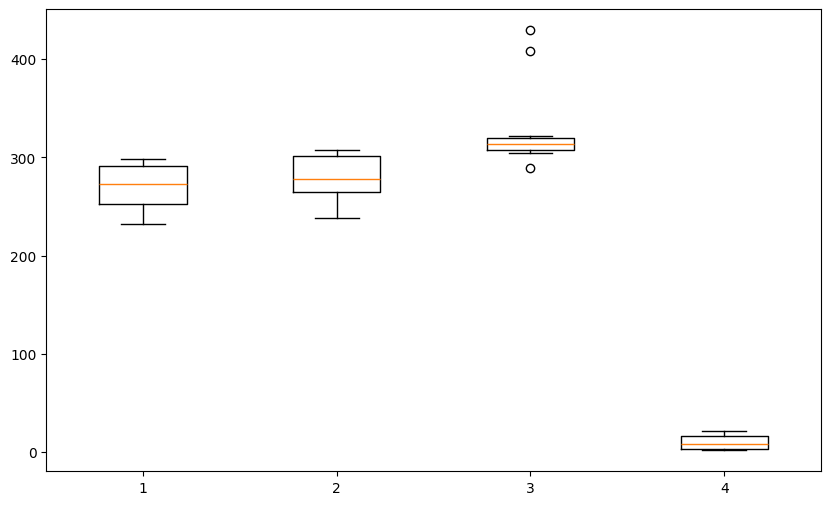

In [9]:
analyse_working_time(time_summary_df)


### Single Filter Analysis

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.54%
F1-score: 2.54%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.58%
F1-score: 2.58%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.10%
F1-score: 0.10%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
=========== Clustering Filters ==============


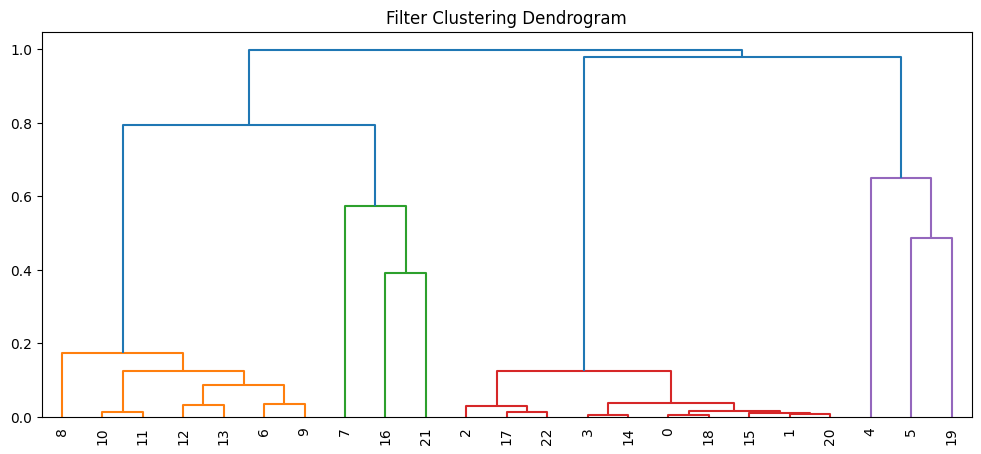

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 10.25%
F1-score: 10.25%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.91%
F1-score: 8.91%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.91%
F1-score: 1.91%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.70%
F1-score: 1.70%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.96%
F1-score: 2.96%
=========== Clustering Filters ==============


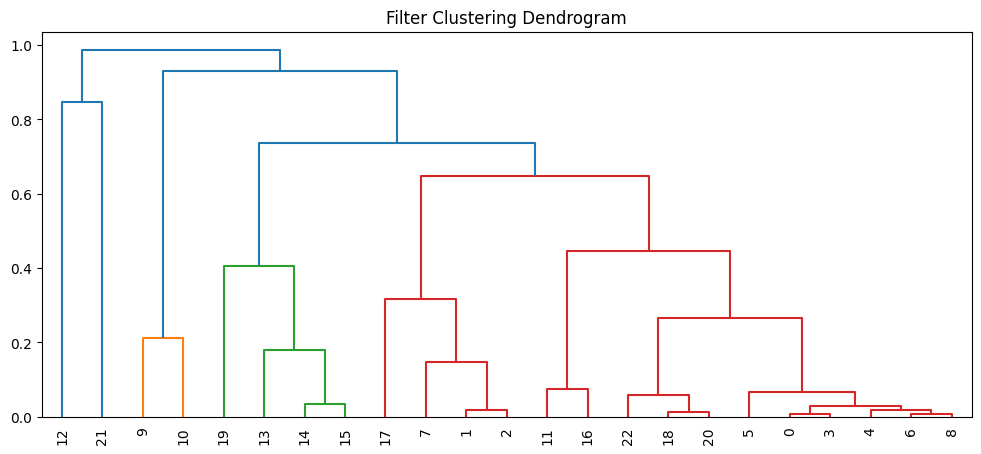

=========== Analysing Fold 2 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 45.20%
F1-score: 45.20%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 55.34%
F1-score: 55.34%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 71.52%
F1-score: 71.52%
Analyzing filter: 19
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 7.60%
F1-score: 7.60%
Analyzing filter: 20
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 14.45%
F1-score: 14.45%
=========== Clustering Filters ==============


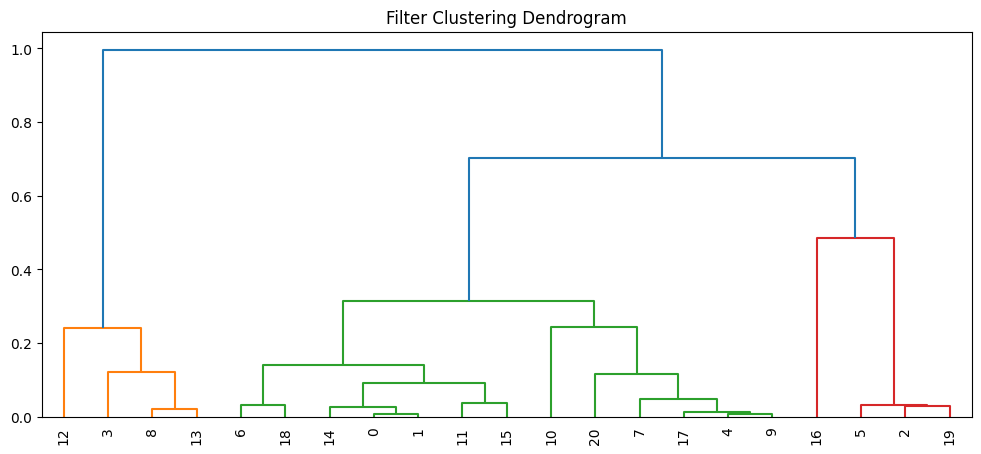

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.14%
F1-score: 7.14%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.29%
F1-score: 0.29%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.18%
F1-score: 0.18%
=========== Clustering Filters ==============


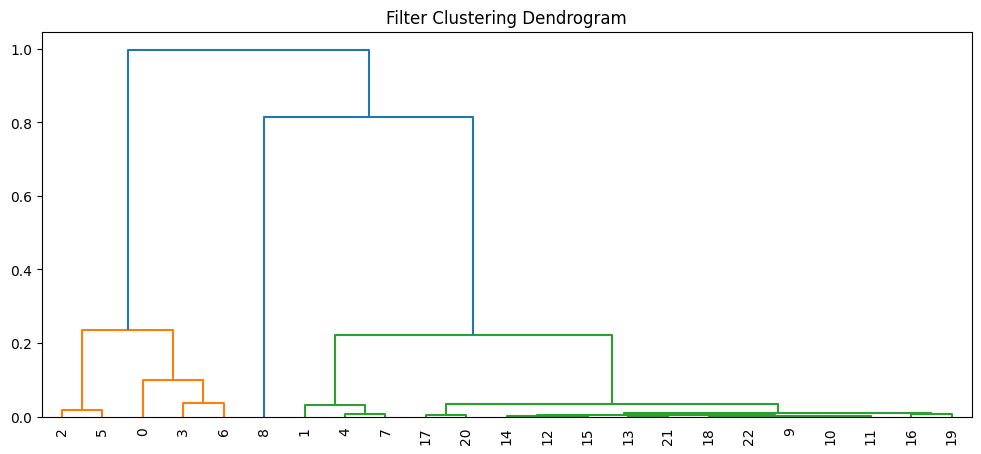

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 31.89%
F1-score: 31.89%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 32.35%
F1-score: 32.35%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 29.19%
F1-score: 29.19%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.82%
F1-score: 29.82%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.57%
F1-score: 37.57%
=========== Clustering Filters ==============


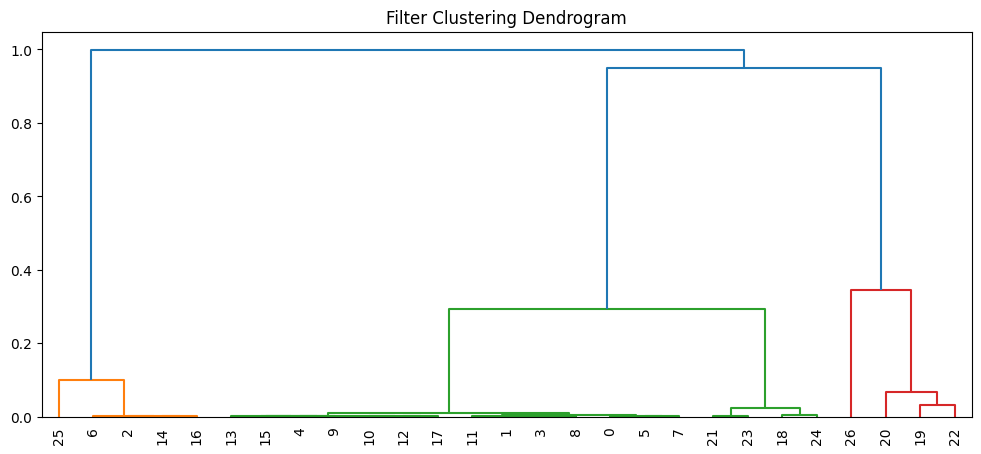

[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0  [0.82672465, 0.8239001, 0.85710967, 0.84401697...   
1 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 22.70%
F1-score: 22.70%
Analyzing filter: 1


...

=========== Finding Best Threshold ==============
F1-score: 2.59%
F1-score: 2.59%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 31.43%
F1-score: 31.43%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.59%
F1-score: 2.59%
=========== Clustering Filters ==============


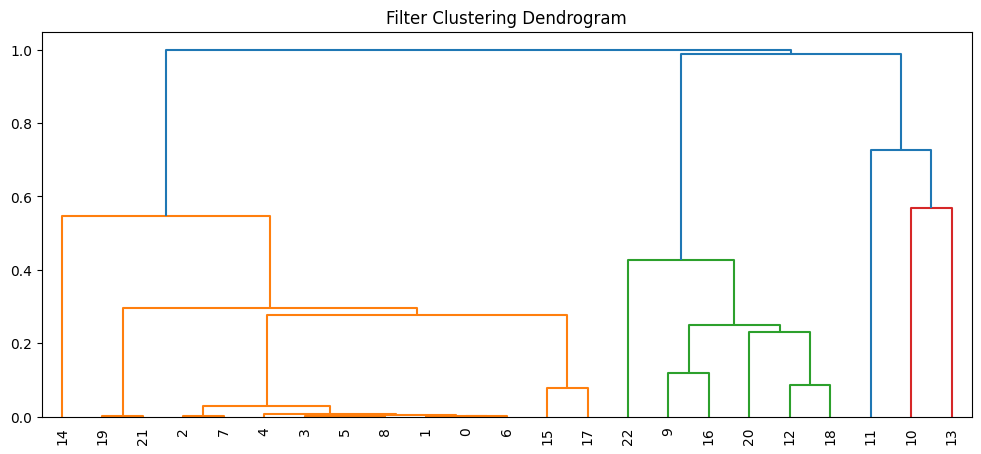

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.08%
F1-score: 0.08%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

=========== Finding Best Threshold ==============
F1-score: 0.06%
F1-score: 0.06%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.06%
F1-score: 0.06%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
=========== Clustering Filters ==============


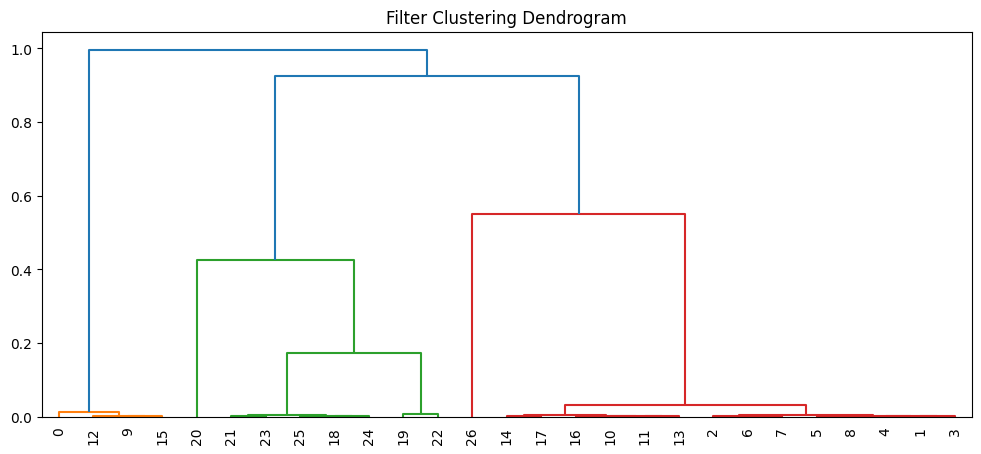

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 3.62%
F1-score: 3.62%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 3.61%
F1-score: 3.61%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 3.42%
F1-score: 3.42%
Analyzing filter: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 4.67%
F1-score: 4.67%
Analyzing filter: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 3.41%
F1-score: 3.41%
=========== Clustering Filters ==============


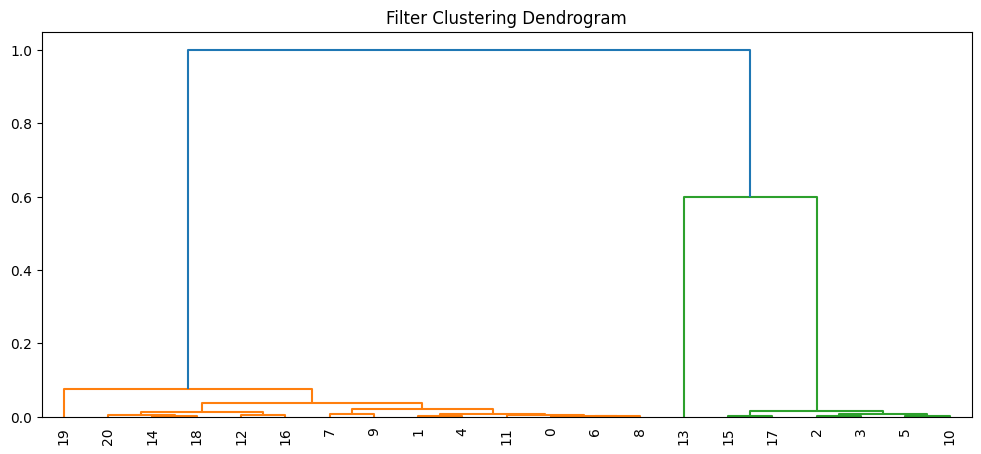

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.48%
F1-score: 0.48%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.63%
F1-score: 0.63%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.69%
F1-score: 0.69%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.52%
F1-score: 0.52%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.63%
F1-score: 0.63%
=========== Clustering Filters ==============


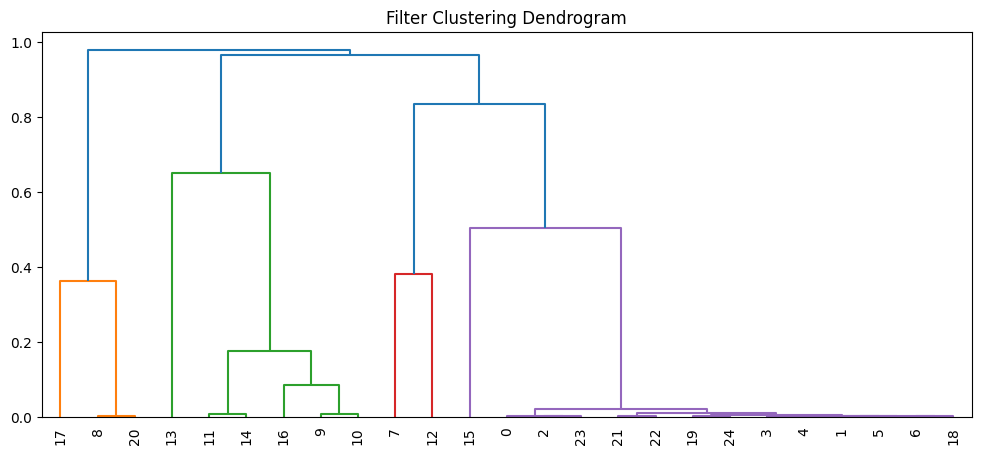

=========== Analysing Fold 4 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.41%
F1-score: 0.41%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.35%
F1-score: 0.35%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.30%
F1-score: 0.30%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 1.82%
F1-score: 1.82%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.34%
F1-score: 0.34%
=========== Clustering Filters ==============


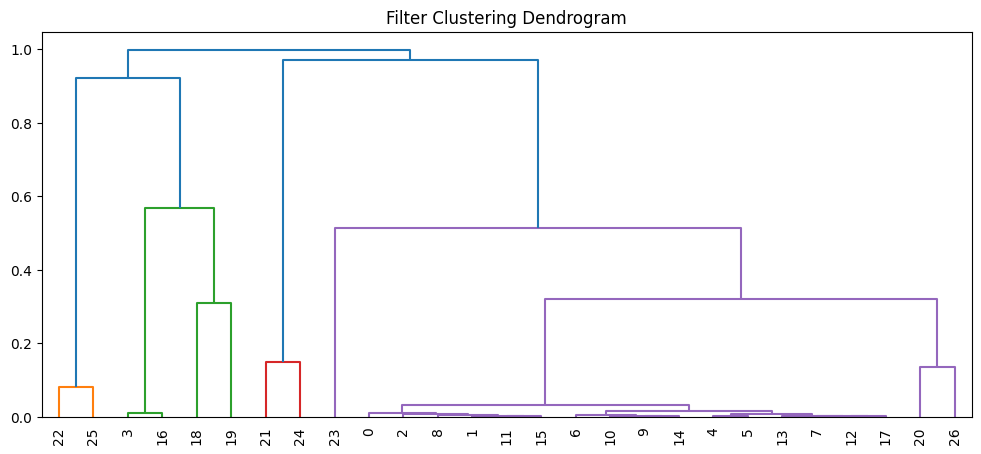

no filters selected. Extract the best one in the backup
[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 69.93%
F1-score: 69.93%
Analyzing filter: 1


...

=========== Finding Best Threshold ==============
F1-score: 0.72%
F1-score: 0.72%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.09%
F1-score: 0.09%
=========== Clustering Filters ==============


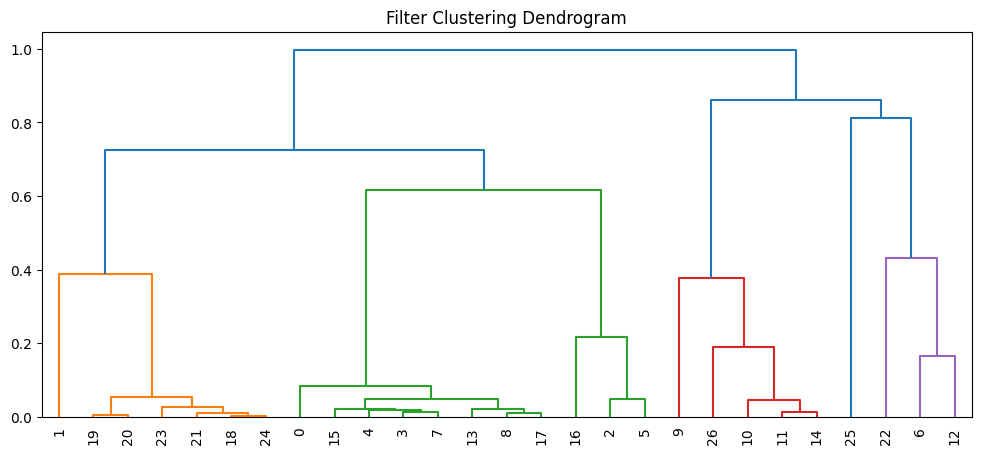

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.24%
F1-score: 7.24%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.57%
F1-score: 7.57%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.41%
F1-score: 1.41%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.97%
F1-score: 1.97%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.37%
F1-score: 2.37%
=========== Clustering Filters ==============


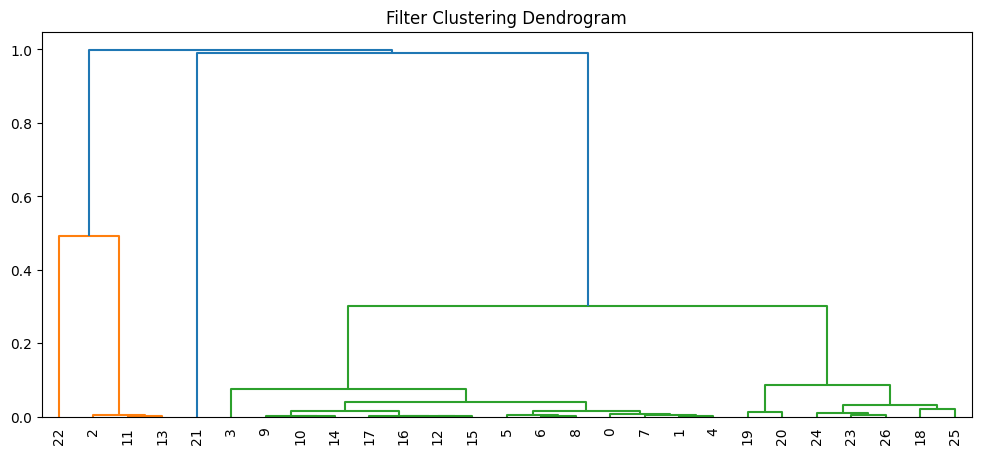

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.05%
F1-score: 1.05%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.31%
F1-score: 1.31%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.26%
F1-score: 1.26%
=========== Clustering Filters ==============


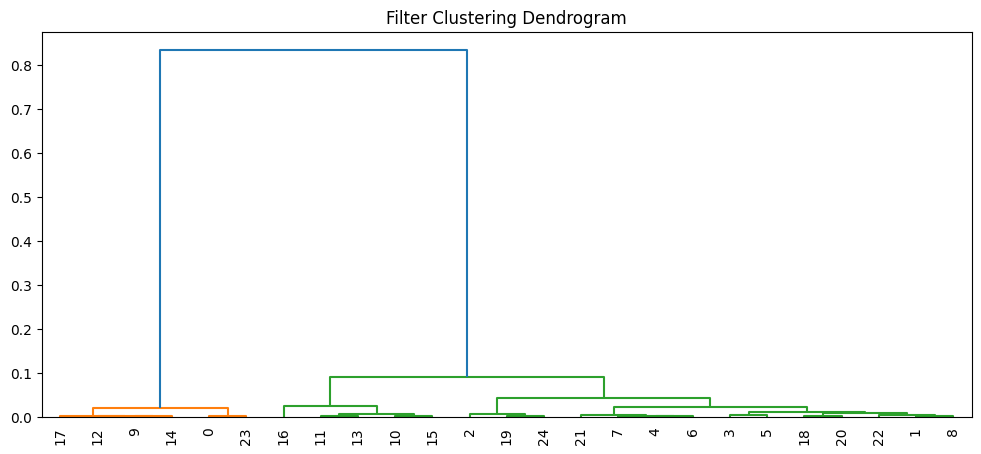

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 34.33%
F1-score: 34.33%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.76%
F1-score: 27.76%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 36.29%
F1-score: 36.29%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 32.20%
F1-score: 32.20%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.86%
F1-score: 27.86%
=========== Clustering Filters ==============


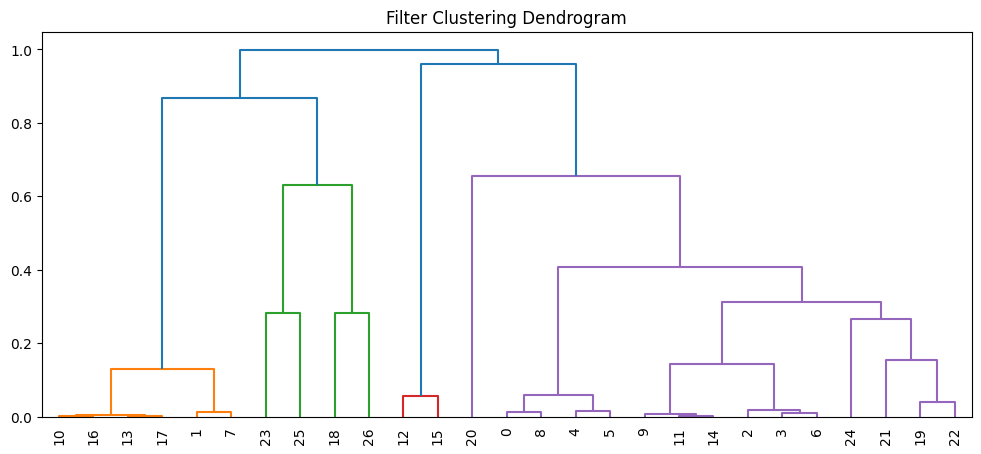

=========== Analysing Fold 4 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 29.77%
F1-score: 29.77%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 37.02%
F1-score: 37.02%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 48.74%
F1-score: 48.74%
Analyzing filter: 15
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 49.99%
F1-score: 49.99%
Analyzing filter: 16
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 45.12%
F1-score: 45.12%
=========== Clustering Filters ==============


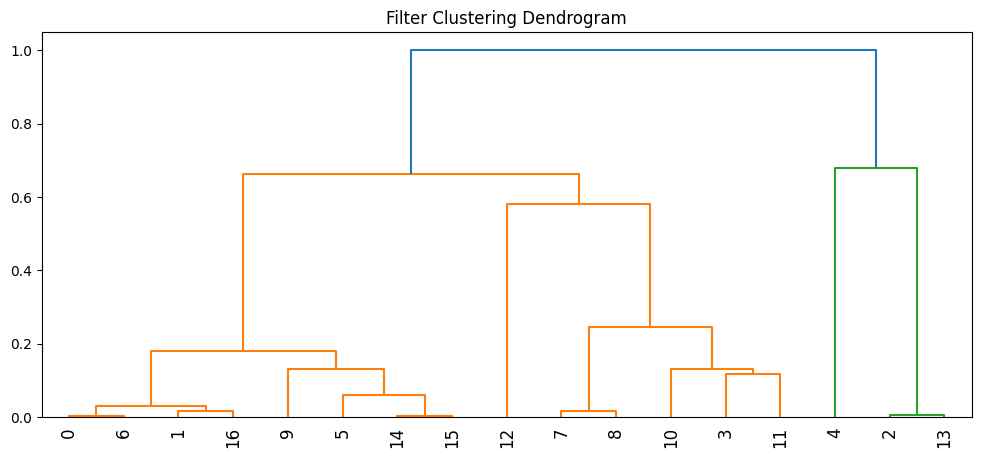

[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0  [0.82672465, 0.8239001, 0.85710967, 0.84401697...   
1 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 1


...

=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.78%
F1-score: 0.78%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.06%
F1-score: 0.06%
=========== Clustering Filters ==============


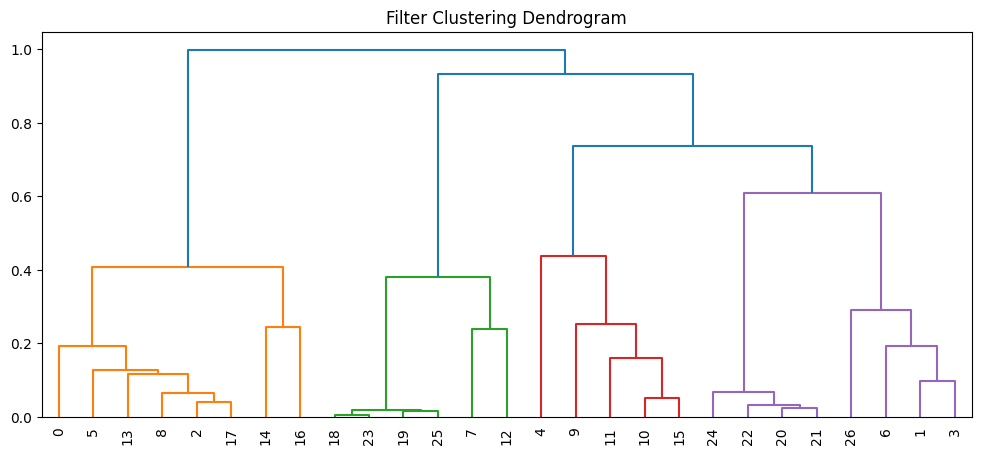

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.00%
F1-score: 0.00%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.01%
F1-score: 0.01%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.01%
F1-score: 0.01%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.00%
F1-score: 0.00%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.03%
F1-score: 0.03%
=========== Clustering Filters ==============


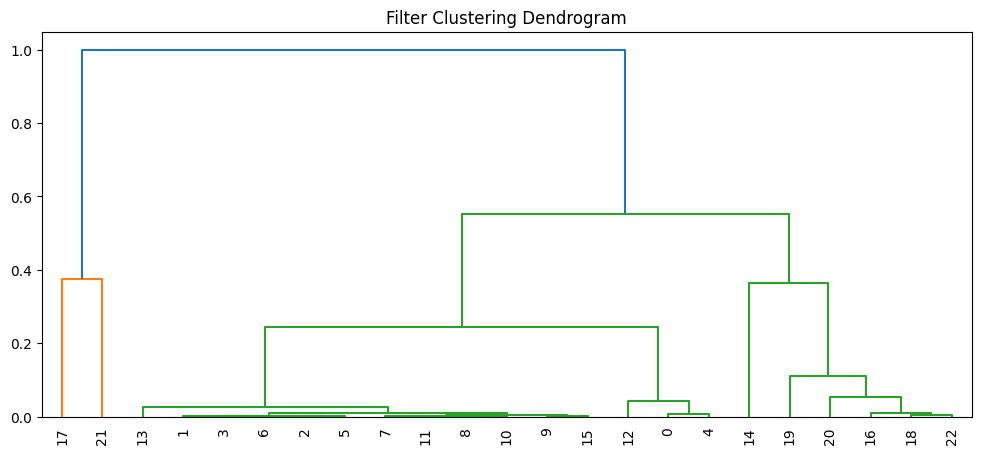

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.51%
F1-score: 0.51%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.50%
F1-score: 0.50%
=========== Clustering Filters ==============


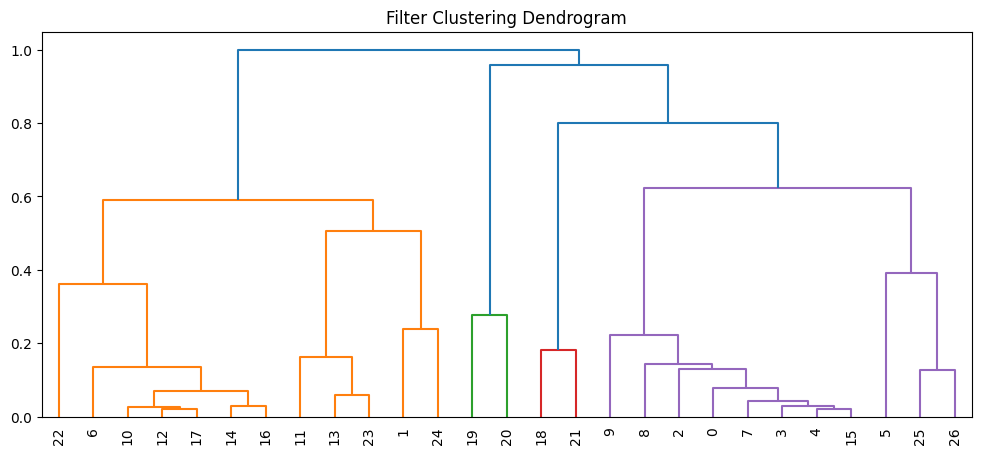

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.34%
F1-score: 27.34%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 32.41%
F1-score: 32.41%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 28.26%
F1-score: 28.26%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.76%
F1-score: 27.76%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 31.94%
F1-score: 31.94%
=========== Clustering Filters ==============


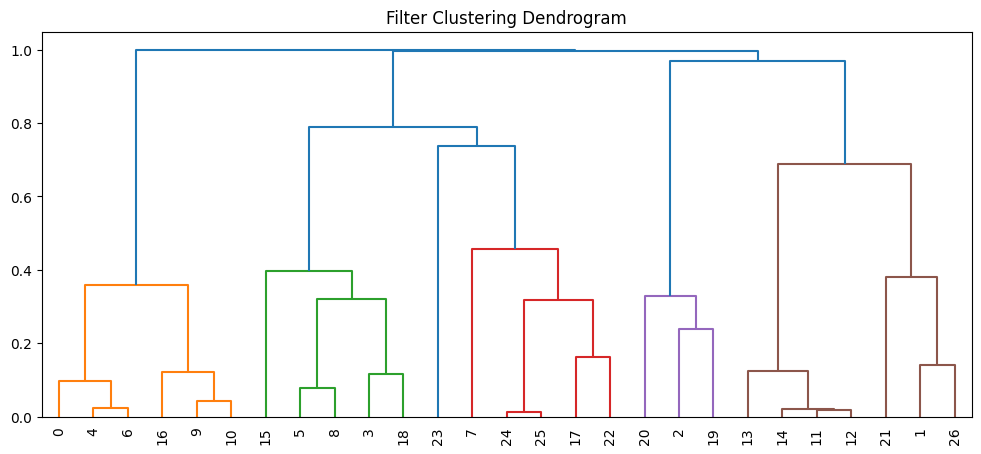

=========== Analysing Fold 4 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 10.02%
F1-score: 10.02%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 7.55%
F1-score: 7.55%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 8.36%
F1-score: 8.36%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 5.01%
F1-score: 5.01%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 22.79%
F1-score: 22.79%
=========== Clustering Filters ==============


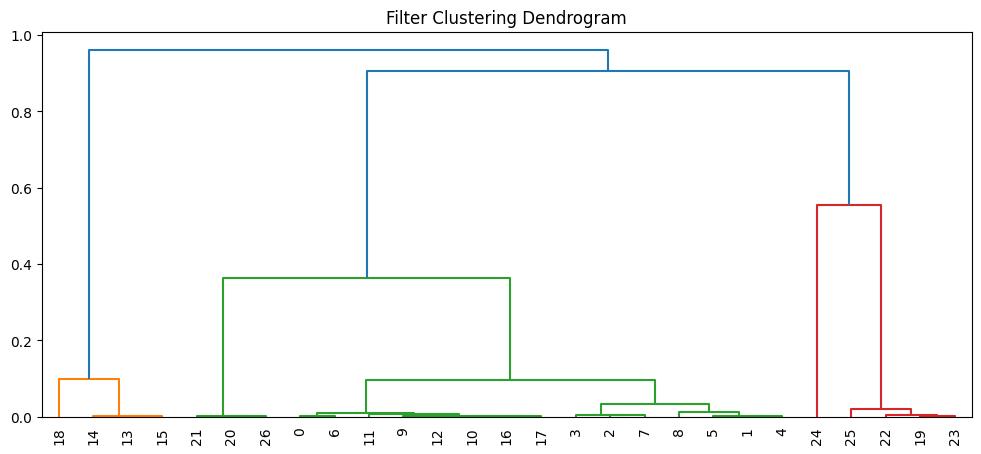

[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0  [0.82672465, 0.8239001, 0.85710967, 0.84401697...   
1 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 38.53%
F1-score: 38.53%
Analyzing filter: 1


...

=========== Finding Best Threshold ==============
F1-score: 37.45%
F1-score: 37.45%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 30.56%
F1-score: 30.56%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.22%
F1-score: 29.22%
=========== Clustering Filters ==============


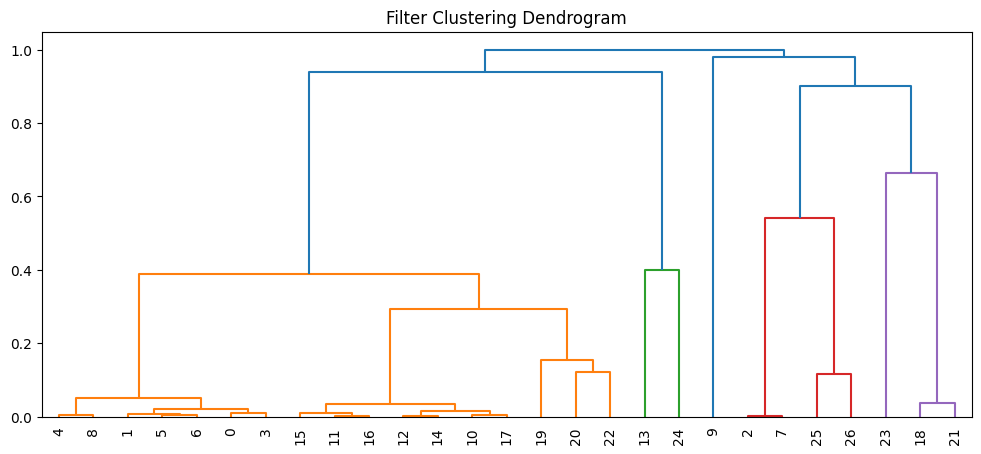

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.00%
F1-score: 0.00%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.01%
F1-score: 0.01%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.00%
F1-score: 0.00%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.07%
F1-score: 0.07%
Analyzing filter: 22
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.04%
F1-score: 0.04%
=========== Clustering Filters ==============


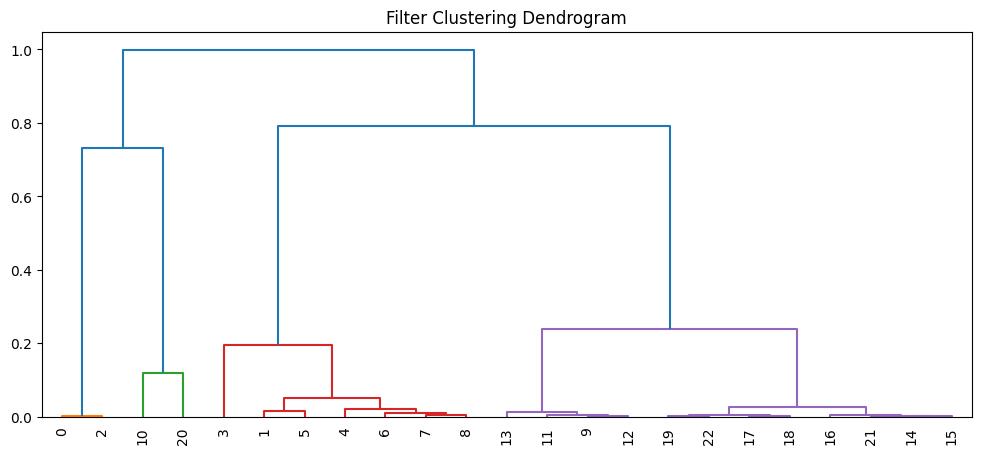

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.14%
F1-score: 2.14%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 38.77%
F1-score: 38.77%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 2.09%
F1-score: 2.09%
Analyzing filter: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.42%
F1-score: 0.42%
Analyzing filter: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.12%
F1-score: 0.12%
=========== Clustering Filters ==============


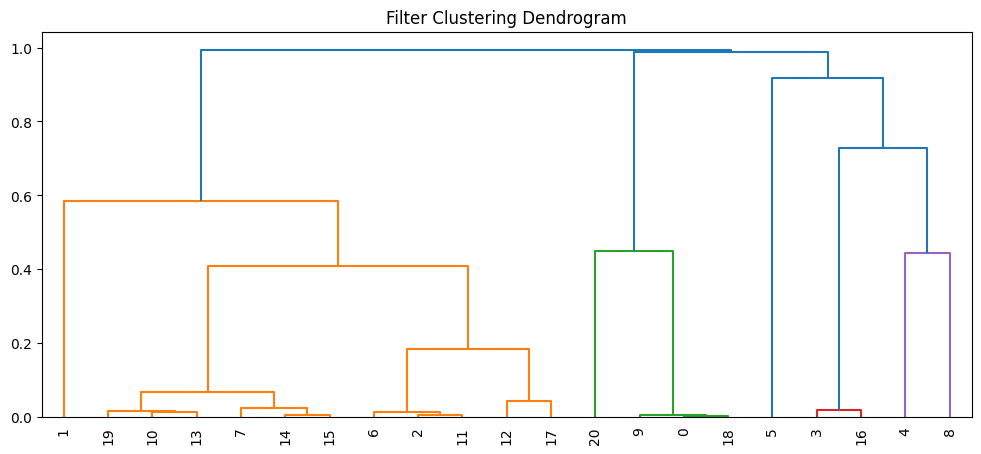

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.07%
F1-score: 0.07%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.23%
F1-score: 0.23%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.11%
F1-score: 0.11%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.10%
F1-score: 0.10%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.07%
F1-score: 1.07%
=========== Clustering Filters ==============


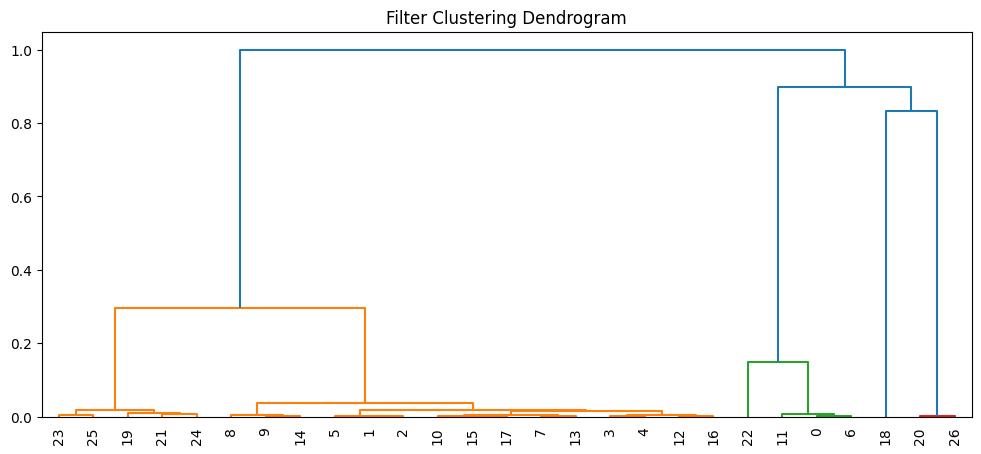

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.22%
F1-score: 0.22%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.15%
F1-score: 0.15%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 4.09%
F1-score: 4.09%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 13.57%
F1-score: 13.57%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.14%
F1-score: 2.14%
=========== Clustering Filters ==============


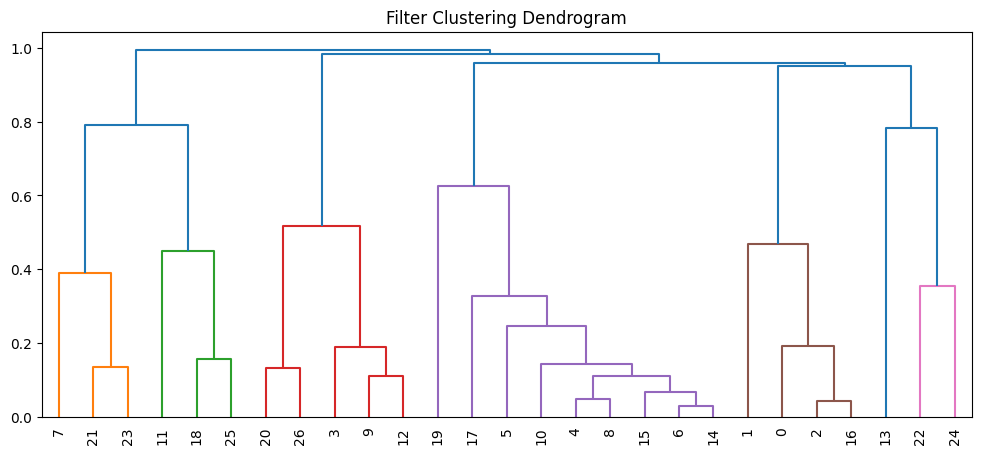

[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0  [0.82672465, 0.8239001, 0.85710967, 0.84401697...   
1 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.49%
F1-score: 8.49%
Analyzing filter: 1


...

=========== Finding Best Threshold ==============
F1-score: 22.21%
F1-score: 22.21%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.90%
F1-score: 8.90%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.53%
F1-score: 0.53%
=========== Clustering Filters ==============


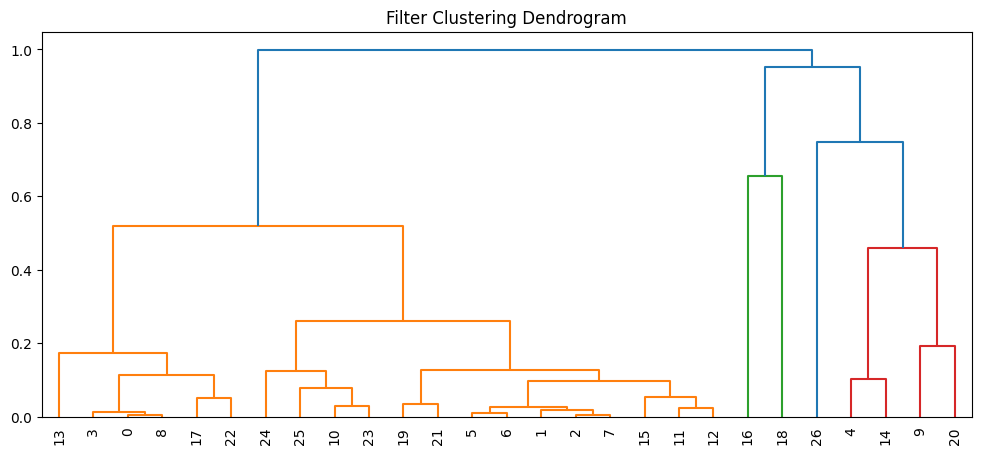

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.14%
F1-score: 0.14%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.62%
F1-score: 2.62%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.96%
F1-score: 1.96%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.04%
F1-score: 2.04%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.99%
F1-score: 1.99%
=========== Clustering Filters ==============


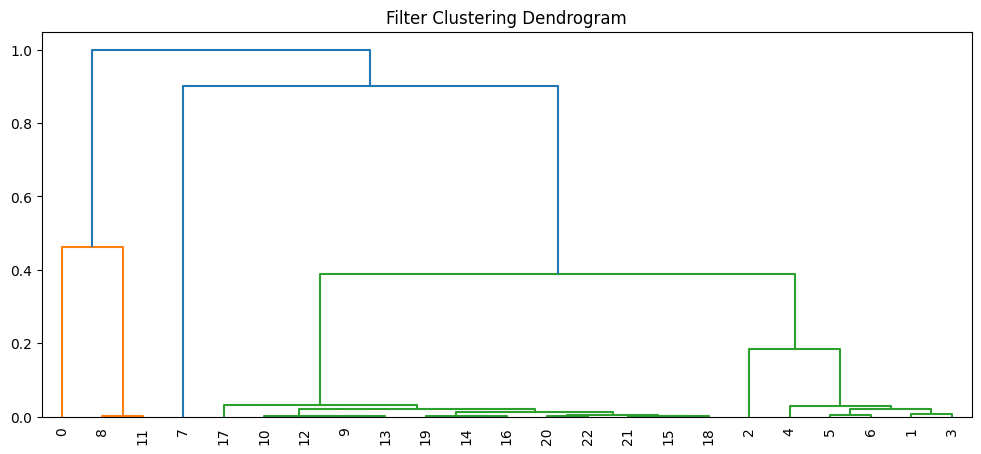

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 40.39%
F1-score: 40.39%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 62.07%
F1-score: 62.07%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 16.57%
F1-score: 16.57%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.46%
F1-score: 2.46%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 49.60%
F1-score: 49.60%
=========== Clustering Filters ==============


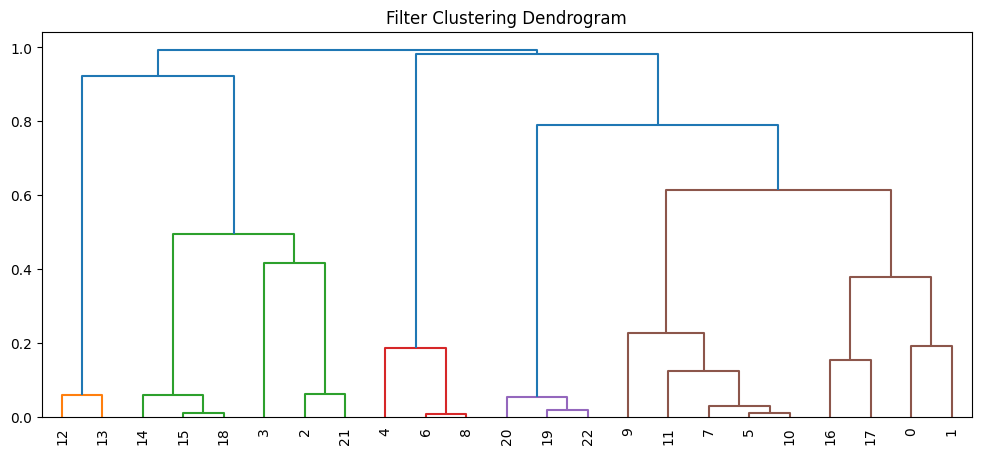

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 41.69%
F1-score: 41.69%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 40.91%
F1-score: 40.91%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 29.34%
F1-score: 29.34%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 57.44%
F1-score: 57.44%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 52.41%
F1-score: 52.41%
=========== Clustering Filters ==============


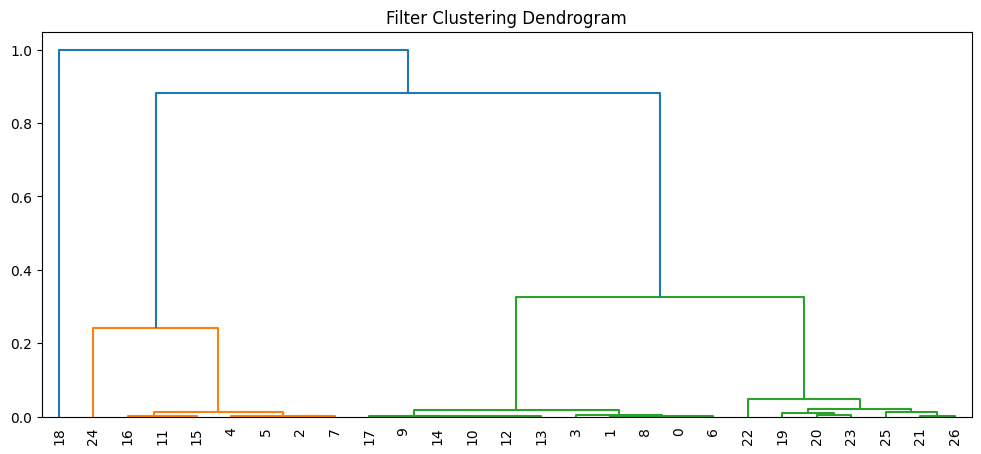

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.74%
F1-score: 0.74%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.83%
F1-score: 0.83%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.06%
F1-score: 0.06%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 48.88%
F1-score: 48.88%
=========== Clustering Filters ==============


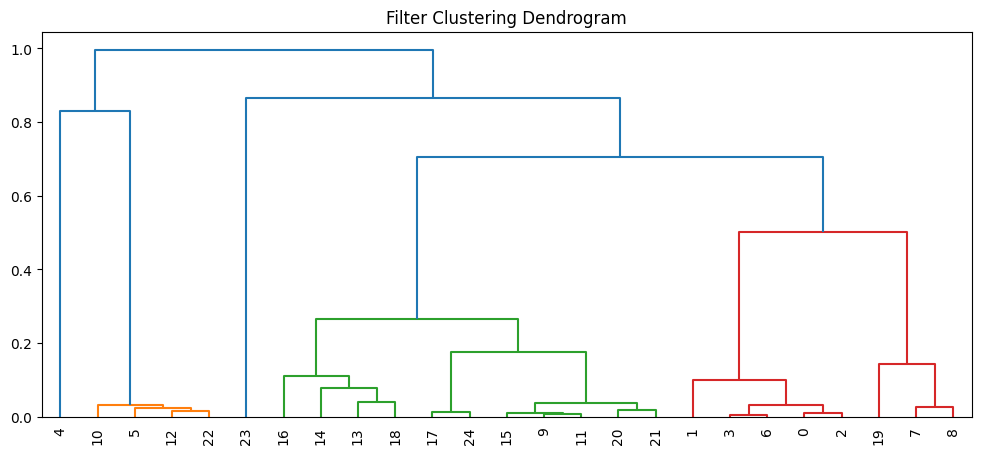

[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0  [0.82672465, 0.8239001, 0.85710967, 0.84401697...   
1 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 0 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 12.57%
F1-score: 12.57%
Analyzing filter: 1
=========== Finding Best Threshold ==============


...

F1-score: 18.30%
F1-score: 18.30%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 5.01%
F1-score: 5.01%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 5.01%
F1-score: 5.01%
=========== Clustering Filters ==============


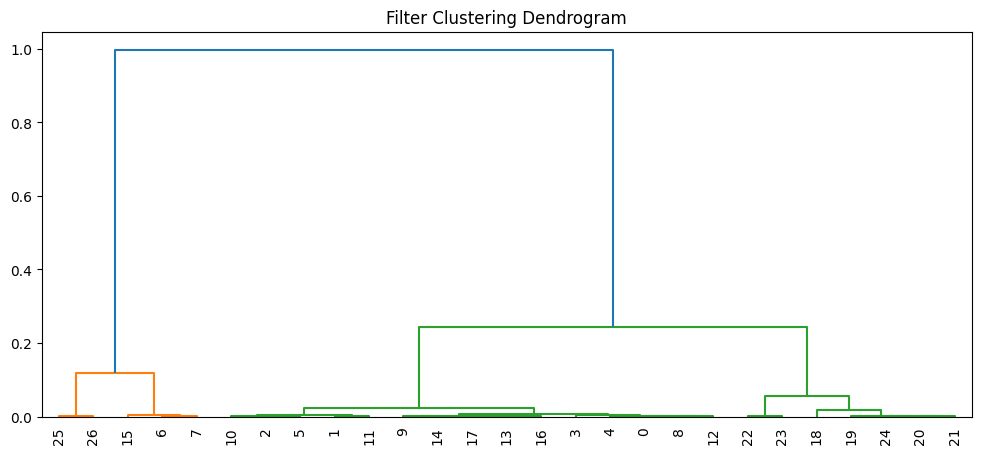

=========== Analysing Fold 1 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.08%
F1-score: 0.08%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.08%
F1-score: 0.08%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.12%
F1-score: 0.12%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.12%
F1-score: 0.12%
=========== Clustering Filters ==============


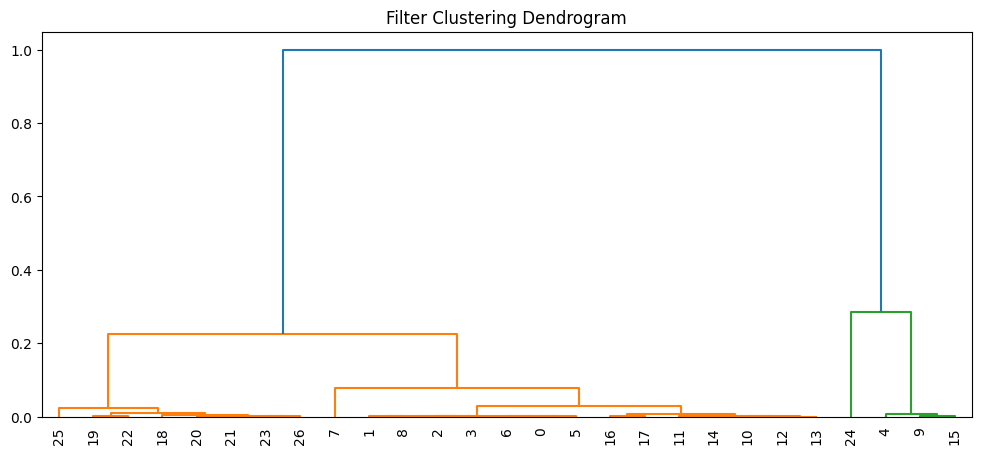

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.24%
F1-score: 0.24%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.64%
F1-score: 2.64%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 8.40%
F1-score: 8.40%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.44%
F1-score: 8.44%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.24%
F1-score: 0.24%
=========== Clustering Filters ==============


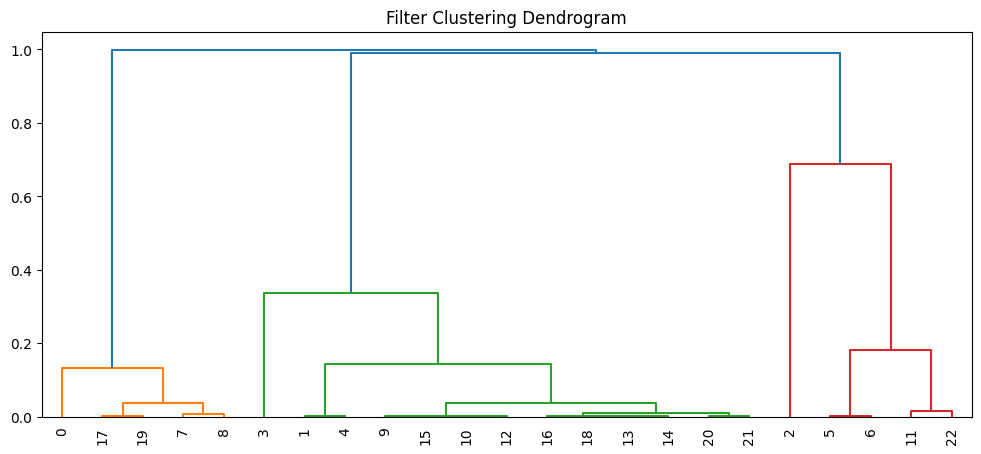

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 23.39%
F1-score: 23.39%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 23.55%
F1-score: 23.55%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 22.65%
F1-score: 22.65%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 23.43%
F1-score: 23.43%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 28.99%
F1-score: 28.99%
=========== Clustering Filters ==============


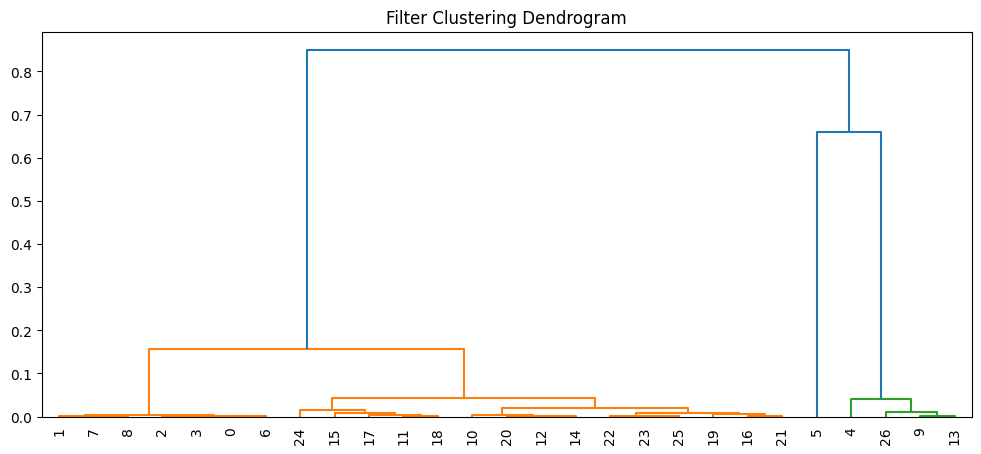

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.61%
F1-score: 2.61%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.65%
F1-score: 2.65%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.15%
F1-score: 0.15%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.31%
F1-score: 2.31%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.35%
F1-score: 2.35%
=========== Clustering Filters ==============


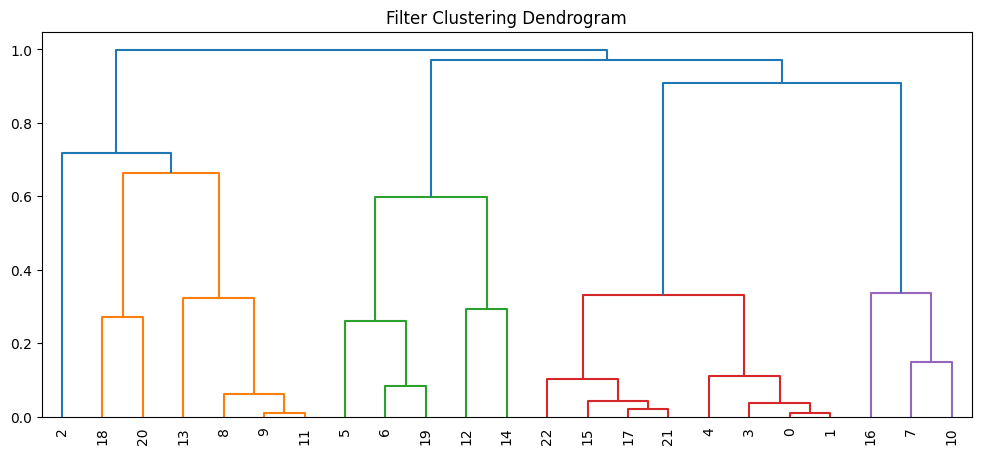

no filters selected. Extract the best one in the backup
[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.11%
F1-score: 0.11%
Analyzing filter: 1


...

=========== Finding Best Threshold ==============
F1-score: 0.34%
F1-score: 0.34%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.04%
F1-score: 1.04%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.11%
F1-score: 0.11%
=========== Clustering Filters ==============


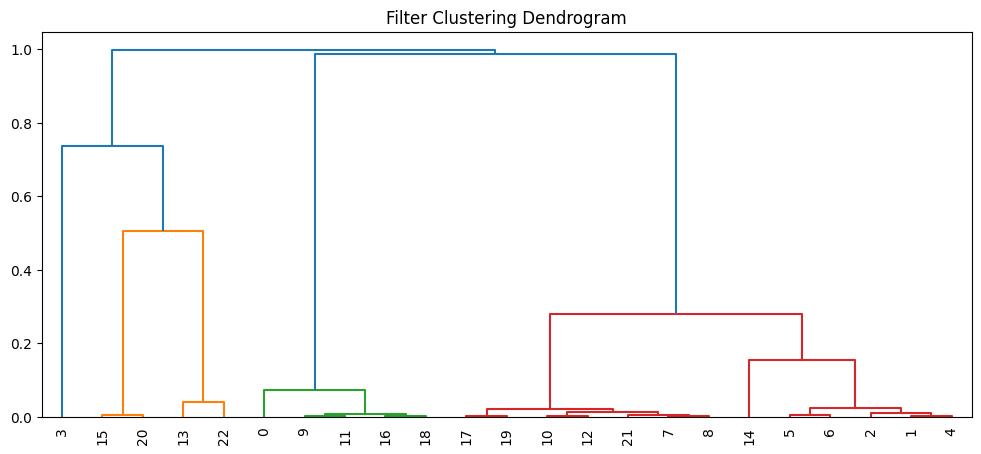

=========== Analysing Fold 1 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.20%
F1-score: 0.20%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.11%
F1-score: 0.11%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.13%
F1-score: 0.13%
=========== Clustering Filters ==============


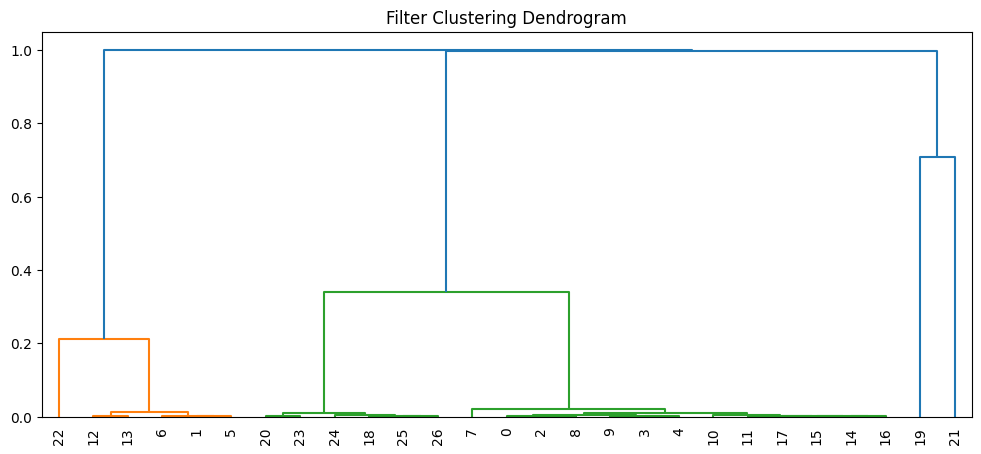

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 35.63%
F1-score: 35.63%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 36.09%
F1-score: 36.09%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 63.45%
F1-score: 63.45%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.93%
F1-score: 37.93%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.28%
F1-score: 27.28%
=========== Clustering Filters ==============


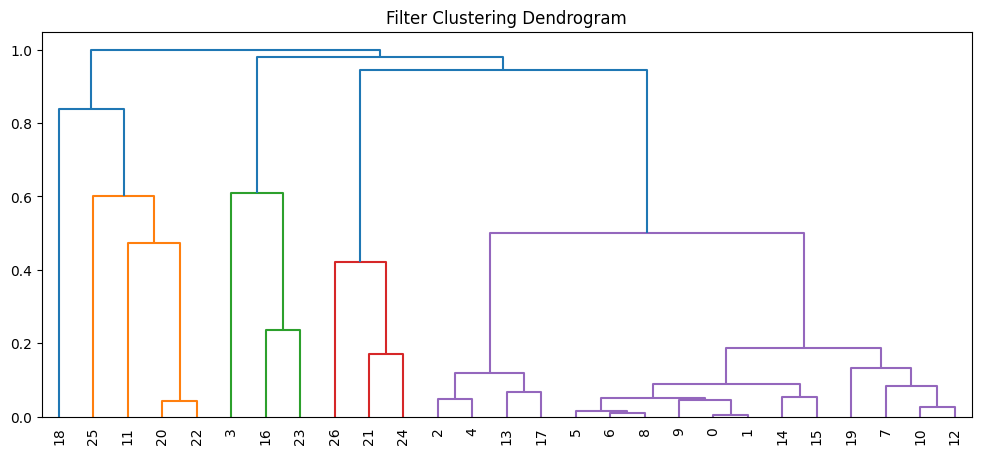

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 11.62%
F1-score: 11.62%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.35%
F1-score: 1.35%
=========== Clustering Filters ==============


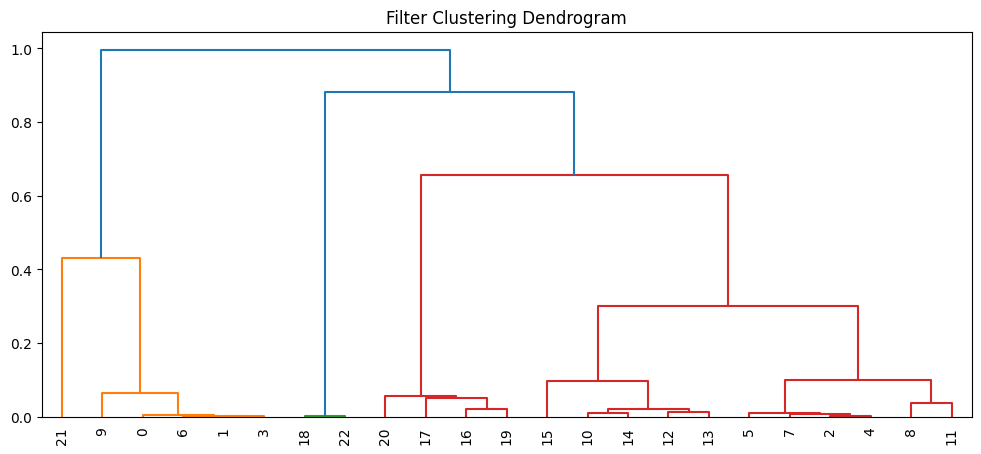

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.04%
F1-score: 0.04%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.47%
F1-score: 0.47%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.04%
F1-score: 0.04%
=========== Clustering Filters ==============


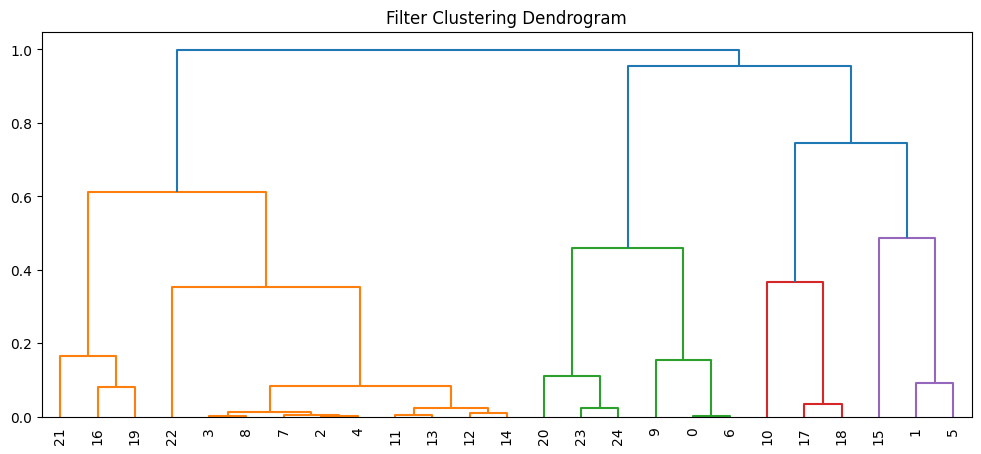

[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0  [0.82672465, 0.8239001, 0.85710967, 0.84401697...   
1 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 5.02%
F1-score: 5.02%
Analyzing filter: 1


...

=========== Finding Best Threshold ==============
F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 5.04%
F1-score: 5.04%
=========== Clustering Filters ==============


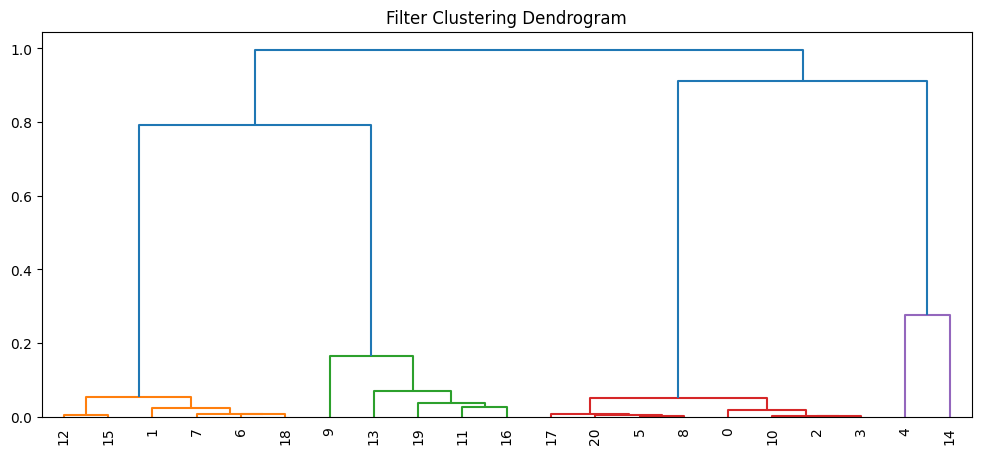

=========== Analysing Fold 1 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.25%
F1-score: 0.25%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.11%
F1-score: 0.11%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 2.68%
F1-score: 2.68%
=========== Clustering Filters ==============


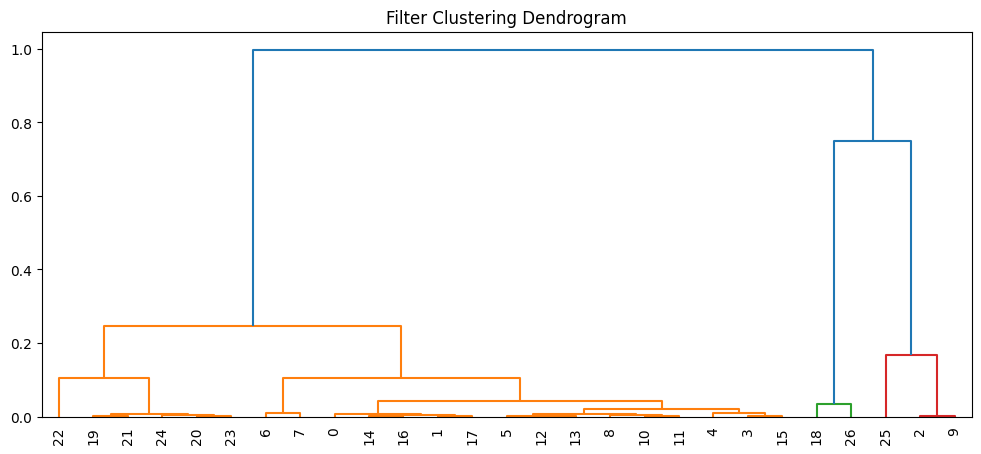

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.03%
F1-score: 0.03%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.03%
F1-score: 0.03%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.03%
F1-score: 0.03%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.33%
F1-score: 0.33%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.17%
F1-score: 0.17%
=========== Clustering Filters ==============


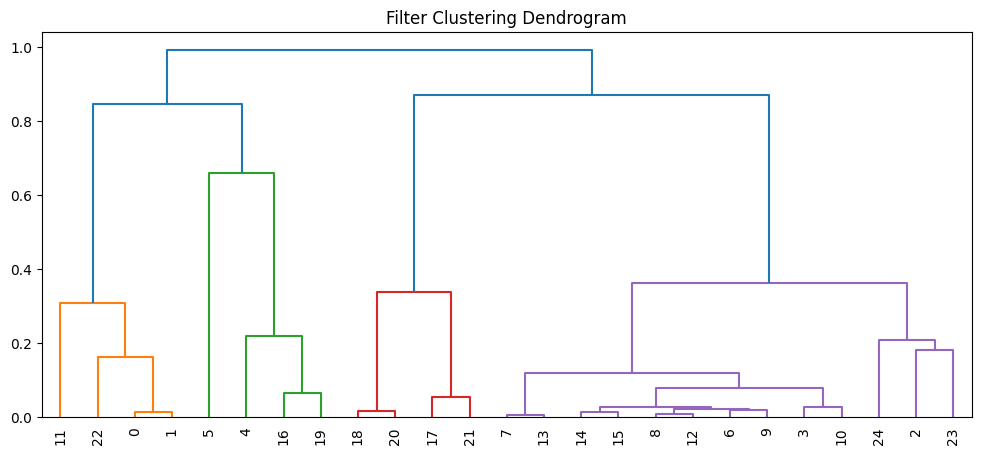

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.16%
F1-score: 29.16%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.16%
F1-score: 29.16%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 33.30%
F1-score: 33.30%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.12%
F1-score: 29.12%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.75%
F1-score: 37.75%
=========== Clustering Filters ==============


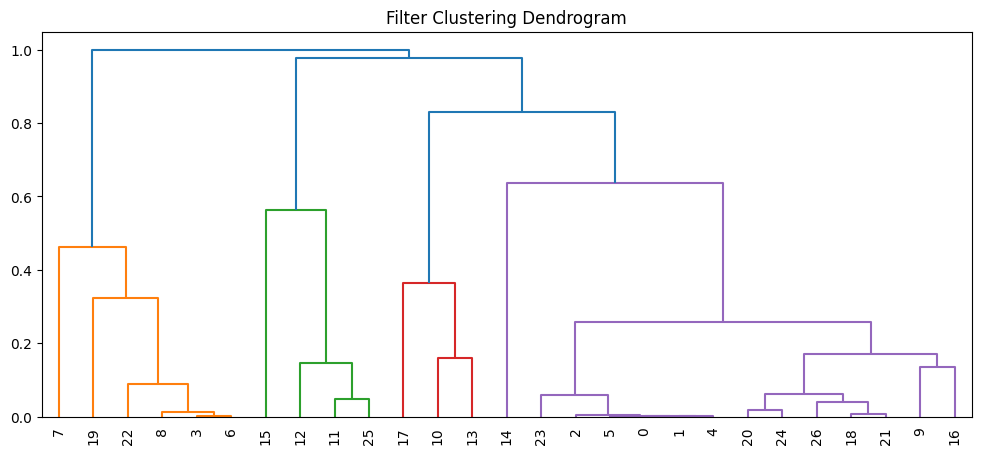

=========== Analysing Fold 4 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.51%
F1-score: 0.51%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.46%
F1-score: 0.46%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 3.66%
F1-score: 3.66%
Analyzing filter: 19
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 1.41%
F1-score: 1.41%
Analyzing filter: 20
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 3.55%
F1-score: 3.55%
=========== Clustering Filters ==============


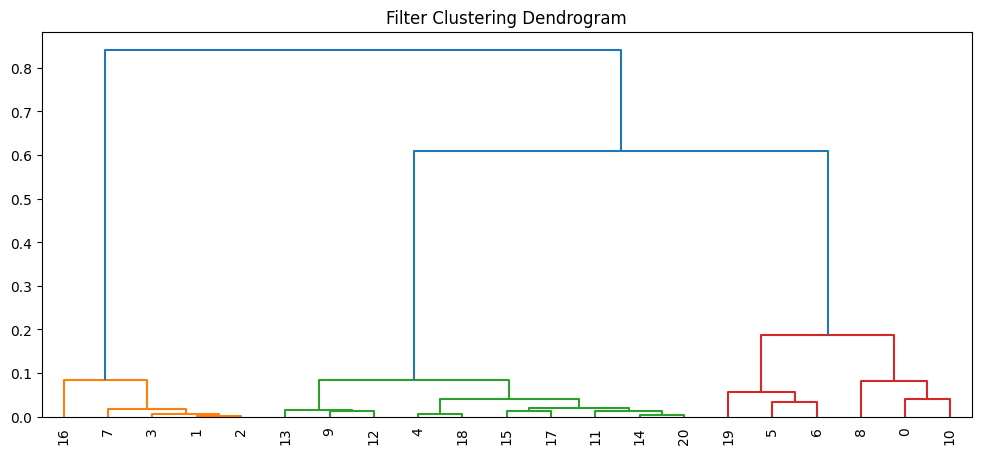

[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0  [0.82672465, 0.8239001, 0.85710967, 0.84401697...   
1 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 34.37%
F1-score: 34.37%
Analyzing filter: 1


...

=========== Finding Best Threshold ==============
F1-score: 34.36%
F1-score: 34.36%
Analyzing filter: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.14%
F1-score: 8.14%
Analyzing filter: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.50%
F1-score: 2.50%
=========== Clustering Filters ==============


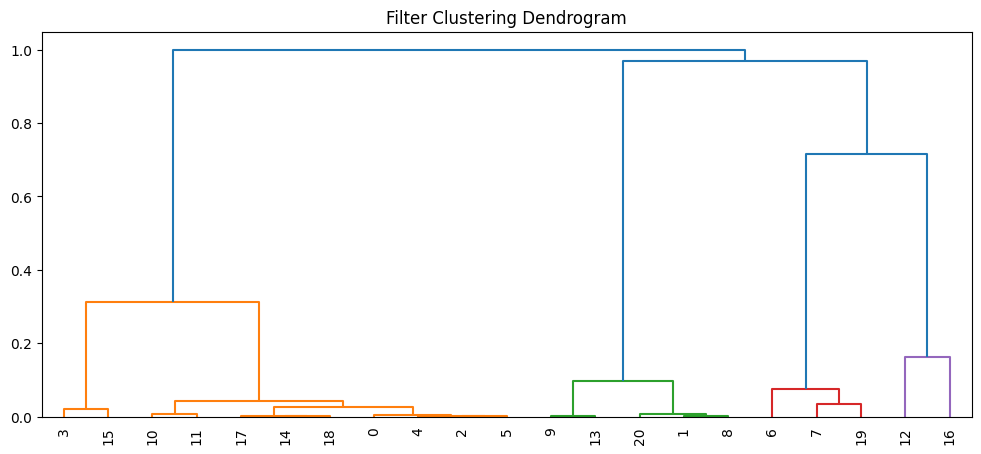

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.07%
F1-score: 0.07%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.12%
F1-score: 0.12%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

=========== Finding Best Threshold ==============
F1-score: 0.15%
F1-score: 0.15%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.44%
F1-score: 0.44%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.13%
F1-score: 0.13%
=========== Clustering Filters ==============


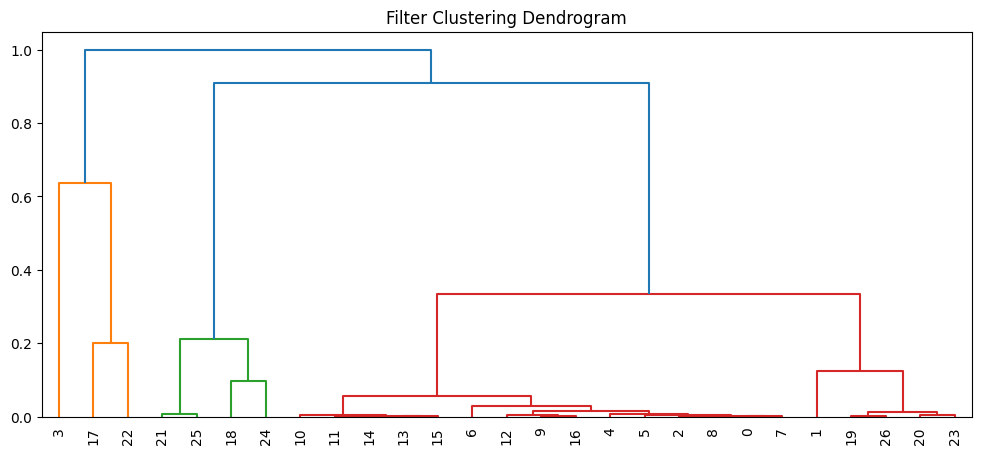

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.32%
F1-score: 1.32%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 3.22%
F1-score: 3.22%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 14.74%
F1-score: 14.74%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.33%
F1-score: 2.33%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.15%
F1-score: 0.15%
=========== Clustering Filters ==============


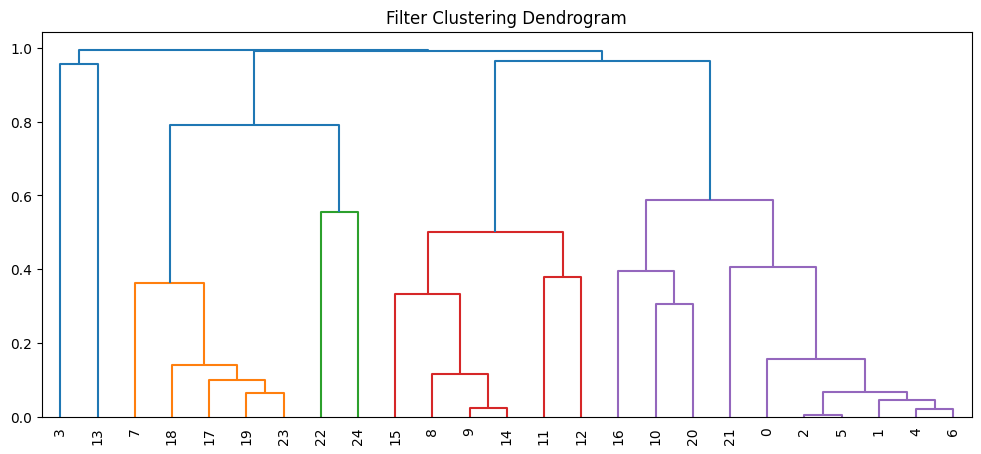

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 22.52%
F1-score: 22.52%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 21.95%
F1-score: 21.95%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 19.61%
F1-score: 19.61%
Analyzing filter: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 19.35%
F1-score: 19.35%
Analyzing filter: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 20.06%
F1-score: 20.06%
=========== Clustering Filters ==============


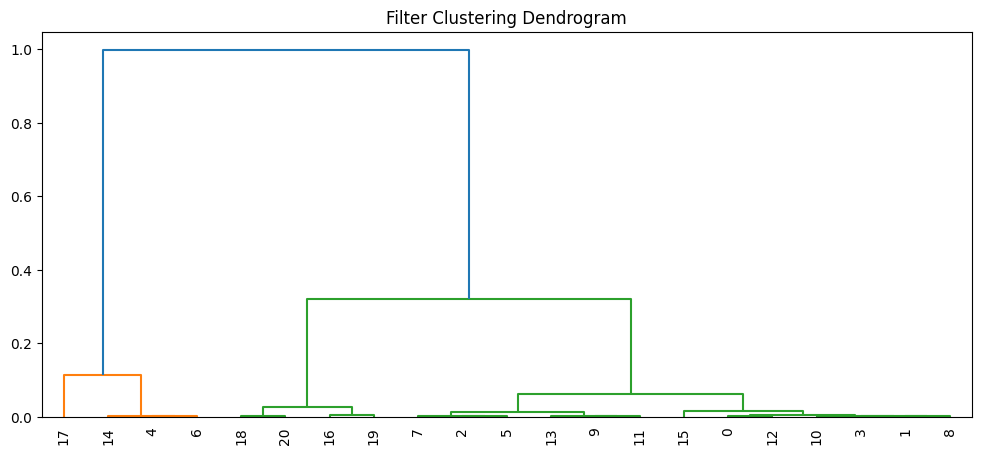

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.41%
F1-score: 8.41%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.12%
F1-score: 8.12%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.05%
F1-score: 1.05%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 6.76%
F1-score: 6.76%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.25%
F1-score: 7.25%
=========== Clustering Filters ==============


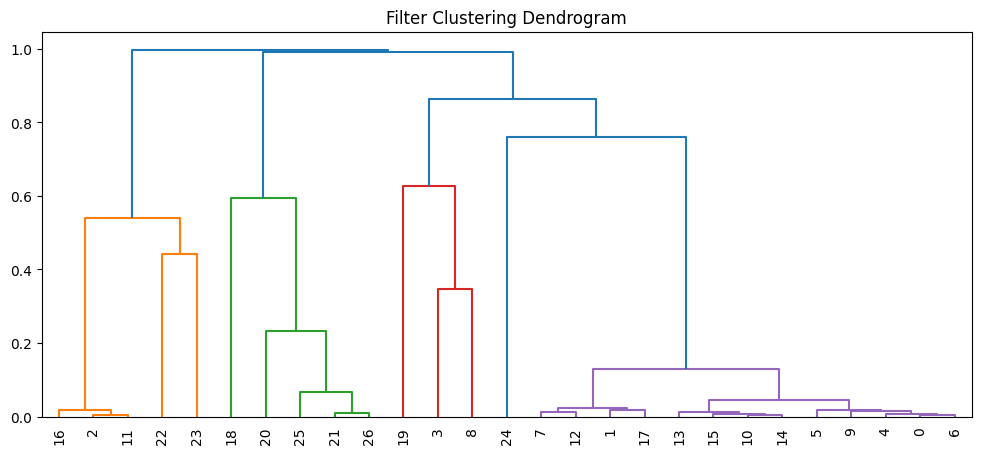

no filters selected. Extract the best one in the backup
[   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                             filters  \
0  [[0.053259388, -0.06652036, -0.055394374, -0.0...   
1  [[-0.10959471, -0.120146774, -0.11739959, 0.09...   
2  [[0.20584126, -0.43999308, -0.5678442, -0.0842...   
3  [[0.098782726, -0.055558875, -0.13801454, 0.32...   
4  [[-0.013904639, -0.2944588, -0.26343158, 0.734...   

                                             scalers  \
0  [StandardScaler(), StandardScaler(), StandardS...   
1  [StandardScaler(), StandardScaler(), StandardS...   
2  [StandardScaler(), StandardScaler(), StandardS...   
3  [StandardScaler(), StandardScaler(), StandardS...   
4  [StandardScaler(), StandardScaler(), StandardS...   

                                            best_thr  \
0 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

In [11]:
folds_to_test = 10
DIST_THRESHOLD = 0.2
FILTER_SEL_THRESHOLD = 0.6

single_filters_test_results = []

entire_pipeline_results = []
best_thr_LOPOCV = []
max_f1_LOPOCV = []
selected_backups_across_LOPOCV_folds = []
LOPO_list = []
LOPO_df = pd.DataFrame()
for LOPOCV_fold_idx in range(folds_to_test):

    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'

    cross_val_models_list = load_training_models(model_cvfolds_dir)
    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold

    # ======= Phase 1: Find Best Filters ======= #

    filter_metadata_df, all_filter_metadata_df = filters_selection_phase(cross_val_models_list, train_kfolds, multiple_donations, ALL_DATASETS, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD)

    LOPO_df = pd.concat([LOPO_df, all_filter_metadata_df], ignore_index=True)

    LOPO_list.append(all_filter_metadata_df)
    print(LOPO_list)

    cols = ['filters', 'scalers', 'best_thr', 'max_f1']
    all_df = all_filter_metadata_df[cols].explode(cols, ignore_index=True)

    for i in range(len(all_df)):
        row = all_df.iloc[i]

        temp_metadata_df = pd.DataFrame({
            'filter_weights': [row['filters']],
            'scaler': [row['scalers']]
        })

        test_results = test_phase(
            filter_metadata_df = temp_metadata_df,
            test_pat = test_pat,
            multiple_donations = multiple_donations,
            ALL_DATASETS = ALL_DATASETS,
            max_f1 = row['max_f1'],
            best_thr = row['best_thr'],
            LOPOCV_fold_idx = LOPOCV_fold_idx
        )

        for res_dict in test_results:
            res_dict['Filter_F1'] = row['max_f1']
            single_filters_test_results.append(res_dict)

final_scatter_df = add_classification_metrics( pd.DataFrame(single_filters_test_results))


filters_plot_exp = 'filter_resp_plots'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{filters_plot_exp}/final_run/'
os.makedirs(config_save_dir, exist_ok = True)
plotdir = os.path.join(config_save_dir, 'plots')
os.makedirs(plotdir, exist_ok = True)

save = False
if save:

    print(plotdir)
    final_scatter_df.to_csv(os.path.join(plotdir, 'final_scatter.csv'), index = False)

In [24]:
    partial_up_df = all_df[all_df['max_f1'] > 0.6]

    if len(partial_up_df) == 0:
        max_f1 = all_df['max_f1'].max()
        partial_up_df = all_df[all_df['max_f1'] == max_f1]
    partial_up_df
    temp_df = pd.DataFrame()
    temp_df['filter_weights'] = partial_up_df['filters']
    temp_df['scaler'] = partial_up_df['scalers']
    print(temp_df)
    temp_metadata_df = pd.DataFrame({
            'filter_weights': [partial_up_df['filters']],
            'scaler': [row['scalers']]
        })
    temp_metadata_df

                                        filter_weights            scaler
102  [-0.04304908, -0.18333314, 0.19712669, -0.1425...  StandardScaler()


,filter_weights,scaler
0,"102 [-0.04304908, -0.18333314, 0.19712669, ...",StandardScaler()


In [19]:
    all_filter_metadata_df = LOPO_list[LOPOCV_fold_idx]
    all_filter_metadata_df
    all_df = all_filter_metadata_df[cols].explode(cols, ignore_index=True)
    all_df

,filters,scalers,best_thr,max_f1
0,"[0.11178924, -0.26116228, -0.07550114, -0.1013...",StandardScaler(),0.769298,0.34371
1,"[0.368289, 0.64812, -0.2567224, -0.031429444, ...",StandardScaler(),0.117853,0.025286
2,"[0.100461885, -0.26208878, -0.06078965, -0.095...",StandardScaler(),0.79656,0.345003
3,"[-0.021557143, -0.44613042, 0.069648534, -0.04...",StandardScaler(),0.53186,0.03696
4,"[0.06604401, -0.21608937, -0.059949845, -0.087...",StandardScaler(),0.779711,0.346348
...,...,...,...,...
116,"[-0.068300255, -0.044863753, -0.048607398, -0....",StandardScaler(),0.175319,0.005251
117,"[-0.009662161, 0.017877787, -0.008478441, -0.0...",StandardScaler(),0.420006,0.005398
118,"[-0.058062162, -0.0086729415, -0.0791597, 0.06...",StandardScaler(),0.571545,0.010494
119,"[-0.011614565, -0.028795658, -0.0464363, -0.03...",StandardScaler(),0.611721,0.067607


In [26]:
folds_to_test = 1
avg_filters_test_results = []

entire_pipeline_results = []
best_thr_LOPOCV = []
max_f1_LOPOCV = []
selected_backups_across_LOPOCV_folds = []

for LOPOCV_fold_idx in range(folds_to_test):

    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'

    cross_val_models_list = load_training_models(model_cvfolds_dir)
    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold

# ensemble and average analysis
    # ======= Phase 1: Find Best Filters ======= #

    filter_metadata_df, all_filter_metadata_df = filters_selection_phase(cross_val_models_list, train_kfolds, multiple_donations, ALL_DATASETS, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD)

    all_df = all_filter_metadata_df[cols].explode(cols, ignore_index=True)
    partial_up_df = all_df[all_df['max_f1'] > 0.6]
    if len(partial_up_df) == 0:
        max_f1 = all_df['max_f1'].max()
        partial_up_df = all_df[all_df['max_f1'] == max_f1]

    temp_metadata_df = pd.DataFrame({
            'filter_weights': [partial_up_df['filters']],
            'scaler': [partial_up_df['scalers']],
            'best_thr': [partial_up_df['best_thr']],
            'max_f1': [partial_up_df['max_f1']]
        })

    test_results = test_phase(
            filter_metadata_df = temp_metadata_df,
            test_pat = test_pat,
            multiple_donations = multiple_donations,
            ALL_DATASETS = ALL_DATASETS,
            max_f1 = partial_up_df['max_f1'],
            best_thr = partial_up_df['best_thr'],
            LOPOCV_fold_idx = LOPOCV_fold_idx
        )

    for res_dict in test_results:
            res_dict['Filter_F1'] = partial_up_df['max_f1']
            avg_filters_test_results.append(res_dict)

    final_scatter_df = add_classification_metrics( pd.DataFrame(avg_filters_test_results))
    final_scatter_df


IndexError: list index out of range

In [12]:
final_scatter_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,Predicted_Blasts,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1,True_Label,True_%,Predicted_%,Recall,Precision,F1_Score,Accuracy
0,Pat_1_1,1,864000,757,463488,756,1,462732,400511,0.025356,1,0.0876,53.6444,99.8679,0.1631,0.3257,46.4429
1,Pat_1_2,1,1947518,0,8534,0,0,8534,1938984,0.025356,0,0.0000,0.4382,0.0000,0.0000,0.0000,99.5618
2,Pat_1_1,1,864000,757,463494,757,0,462737,400506,0.025811,1,0.0876,53.6451,100.0000,0.1633,0.3261,46.4425
3,Pat_1_2,1,1947518,0,8488,0,0,8488,1939030,0.025811,0,0.0000,0.4358,0.0000,0.0000,0.0000,99.5642
4,Pat_1_1,1,864000,757,461333,757,0,460576,402667,0.026214,1,0.0876,53.3950,100.0000,0.1641,0.3277,46.6926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2848,Pat_10_2,10,722000,15,62480,0,15,62480,659505,0.010494,1,0.0021,8.6537,0.0000,0.0000,0.0000,91.3442
2849,Pat_10_1,10,430869,639,59951,47,592,59904,370326,0.067607,1,0.1483,13.9140,7.3552,0.0784,0.1551,85.9595
2850,Pat_10_2,10,722000,15,100423,12,3,100411,621574,0.067607,1,0.0021,13.9090,80.0000,0.0119,0.0238,86.0922
2851,Pat_10_1,10,430869,639,58696,98,541,58598,371632,0.072517,1,0.1483,13.6227,15.3365,0.1670,0.3304,86.2745


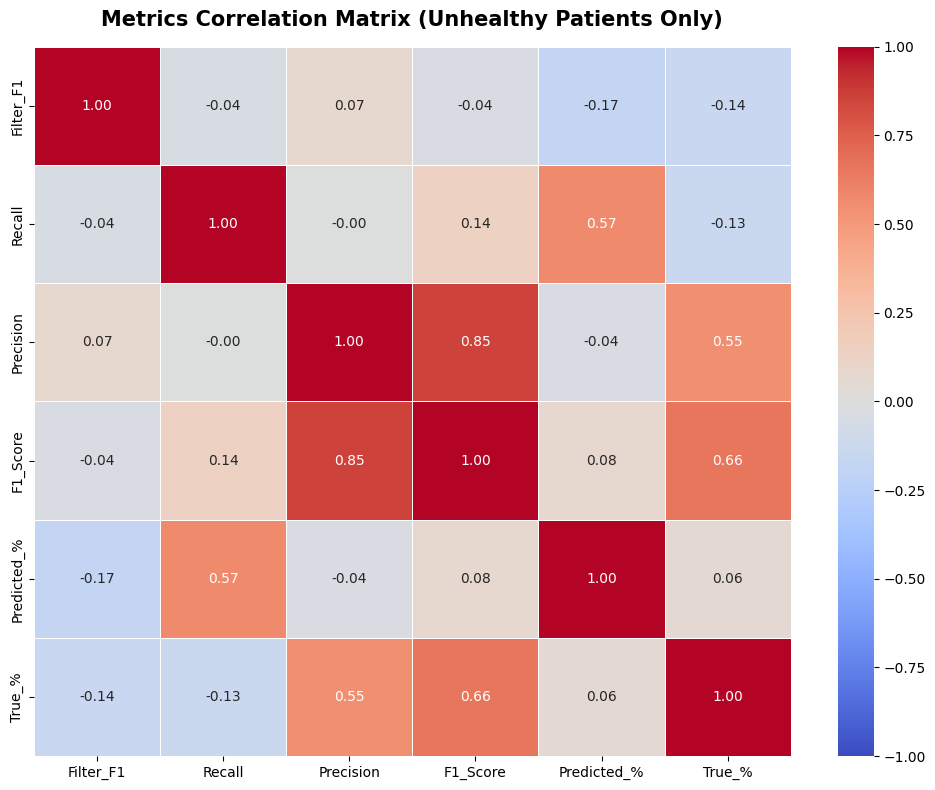

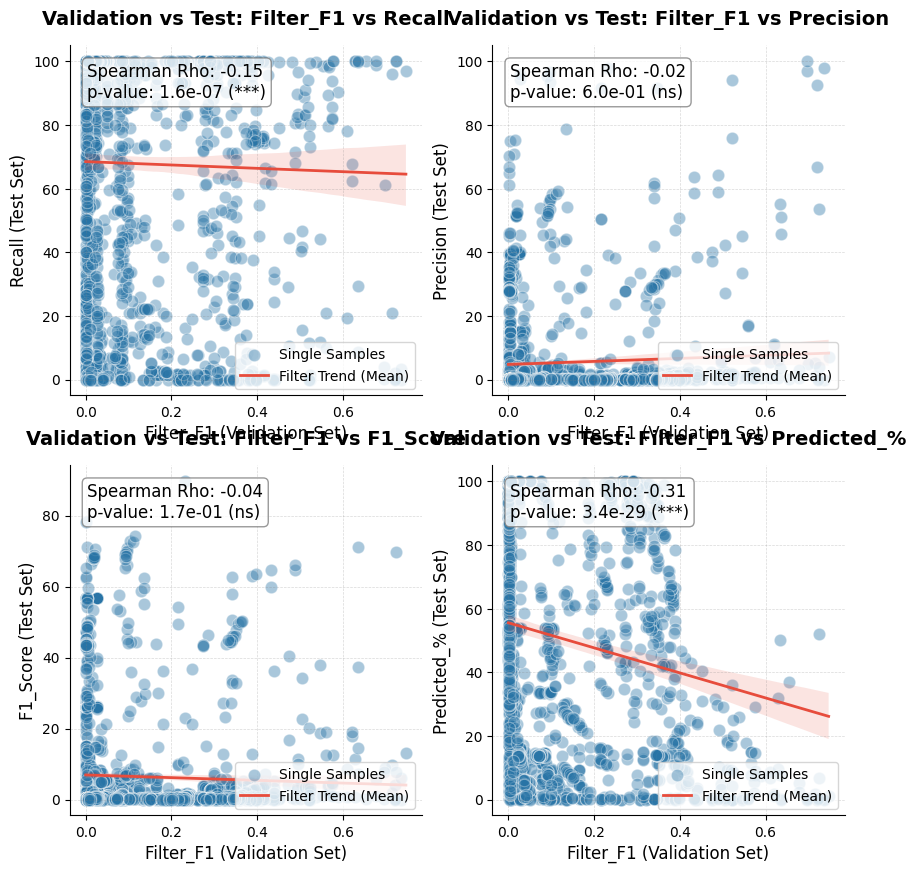

In [14]:


results = PipelineResults(final_scatter_df)

#
results.show_metrics_correlation_matrix(condition='blast')

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for m, metric in enumerate(['Recall', 'Precision', 'F1_Score', 'Predicted_%']):

    results.show_corr(x='Filter_F1', y=metric, condition='blast', axis = axs[m//2, m%2])

display(fig)
plt.close(fig)

In [34]:
final_scatter_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,Predicted_Blasts,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1,True_Label,True_%,Predicted_%,Recall,Precision,F1_Score,Accuracy
0,Pat_1_1,1,864000,757,463488,756,1,462732,400511,0.025356,1,0.0876,53.6444,99.8679,0.1631,0.3257,46.4429
1,Pat_1_2,1,1947518,0,8534,0,0,8534,1938984,0.025356,0,0.0000,0.4382,0.0000,0.0000,0.0000,99.5618
2,Pat_1_1,1,864000,757,463494,757,0,462737,400506,0.025811,1,0.0876,53.6451,100.0000,0.1633,0.3261,46.4425
3,Pat_1_2,1,1947518,0,8488,0,0,8488,1939030,0.025811,0,0.0000,0.4358,0.0000,0.0000,0.0000,99.5642
4,Pat_1_1,1,864000,757,461333,757,0,460576,402667,0.026214,1,0.0876,53.3950,100.0000,0.1641,0.3277,46.6926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2848,Pat_10_2,10,722000,15,62480,0,15,62480,659505,0.010494,1,0.0021,8.6537,0.0000,0.0000,0.0000,91.3442
2849,Pat_10_1,10,430869,639,59951,47,592,59904,370326,0.067607,1,0.1483,13.9140,7.3552,0.0784,0.1551,85.9595
2850,Pat_10_2,10,722000,15,100423,12,3,100411,621574,0.067607,1,0.0021,13.9090,80.0000,0.0119,0.0238,86.0922
2851,Pat_10_1,10,430869,639,58696,98,541,58598,371632,0.072517,1,0.1483,13.6227,15.3365,0.1670,0.3304,86.2745


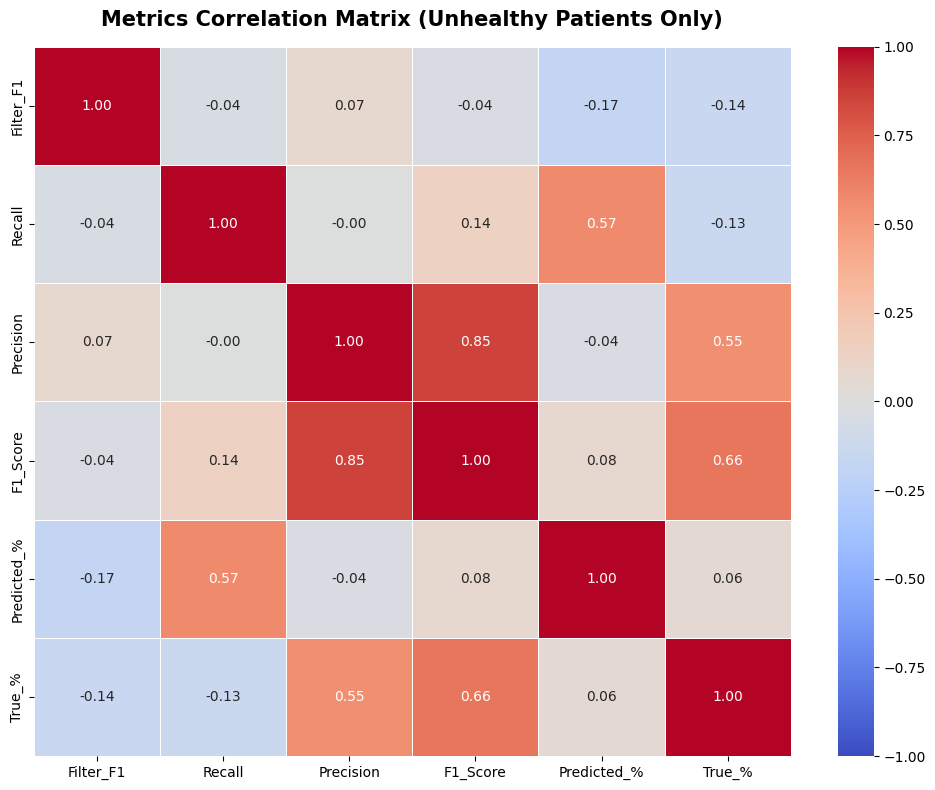

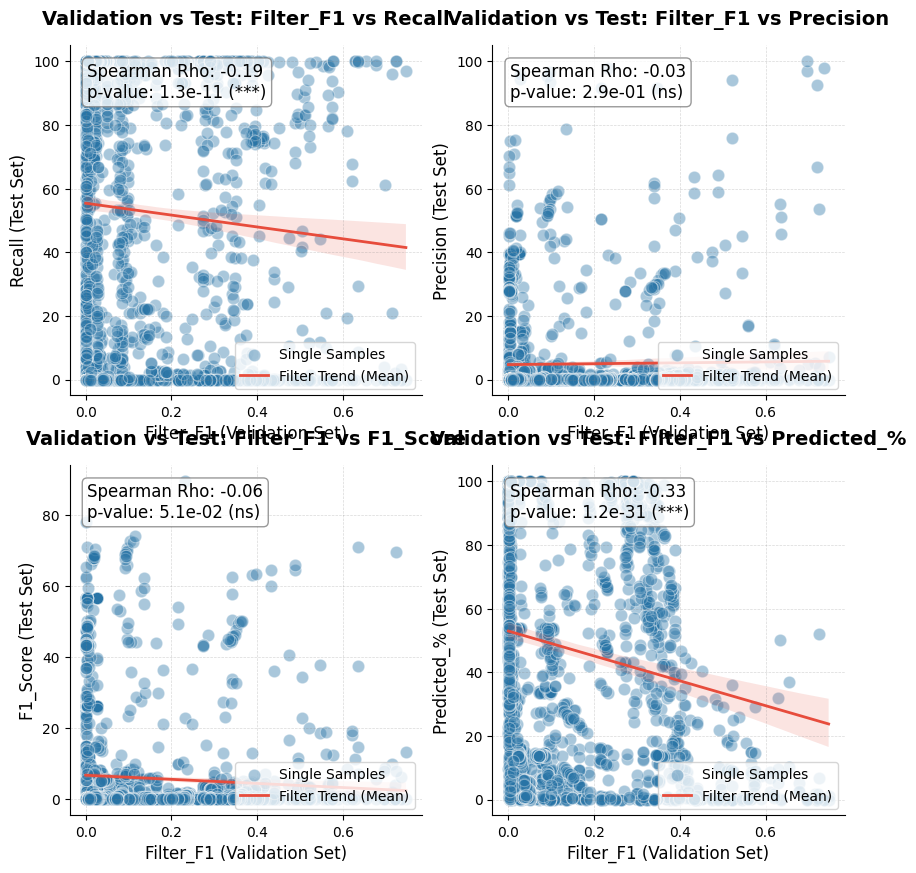

In [39]:


results = PipelineResults(final_scatter_df)

#
results.show_metrics_correlation_matrix(condition='blast')

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for m, metric in enumerate(['Recall', 'Precision', 'F1_Score', 'Predicted_%']):

    results.show_corr(x='Filter_F1', y=metric, condition='None', axis = axs[m//2, m%2])

display(fig)
plt.close(fig)

In [21]:
single_filters_test_results = []
for LOPOCV_fold_idx in range(folds_to_test):

    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'

    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold


    cols = ['filters', 'scalers', 'best_thr', 'max_f1']
    all_df = LOPO_df[LOPO_df['lopo_fold'] == LOPOCV_fold_idx][cols].explode(cols, ignore_index=True)


    for i in range(len(all_df)):
        row = all_df.iloc[i]

        temp_metadata_df = pd.DataFrame({
            'filter_weights': [row['filters']],
            'scaler': [row['scalers']]
        })

        test_results = test_phase(
            filter_metadata_df = temp_metadata_df,
            test_pat = test_pat,
            multiple_donations = multiple_donations,
            ALL_DATASETS = ALL_DATASETS,
            max_f1 = row['max_f1'],
            best_thr = row['best_thr'],
            LOPOCV_fold_idx = LOPOCV_fold_idx
        )

        for res_dict in test_results:
            res_dict['Filter_F1'] = row['max_f1']
            single_filters_test_results.append(res_dict)



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

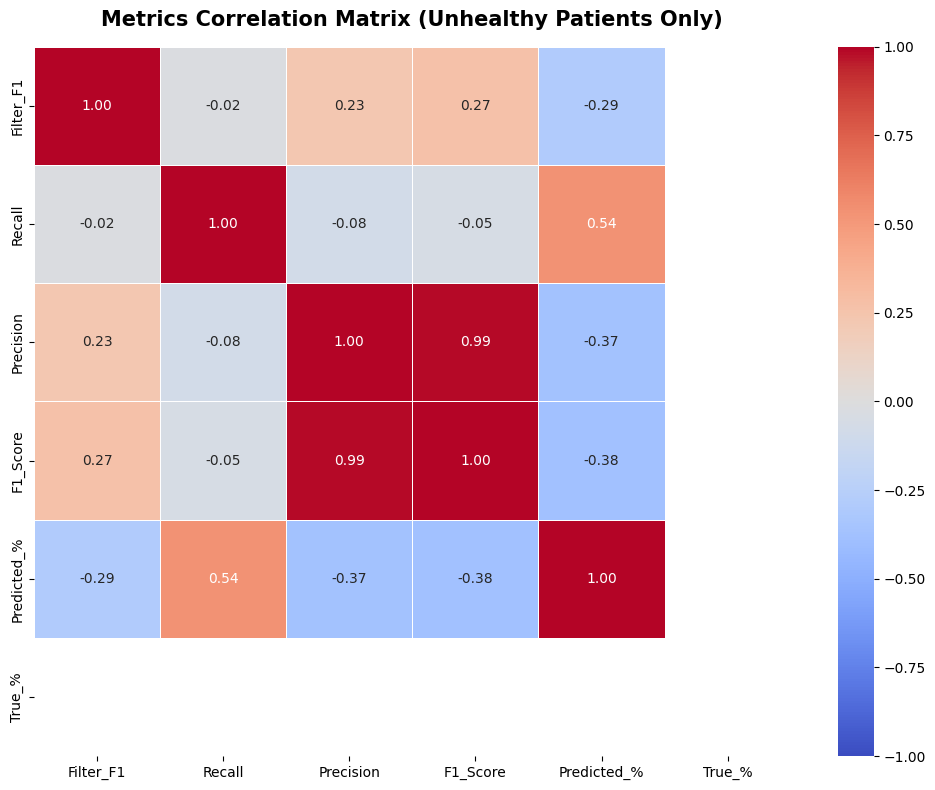

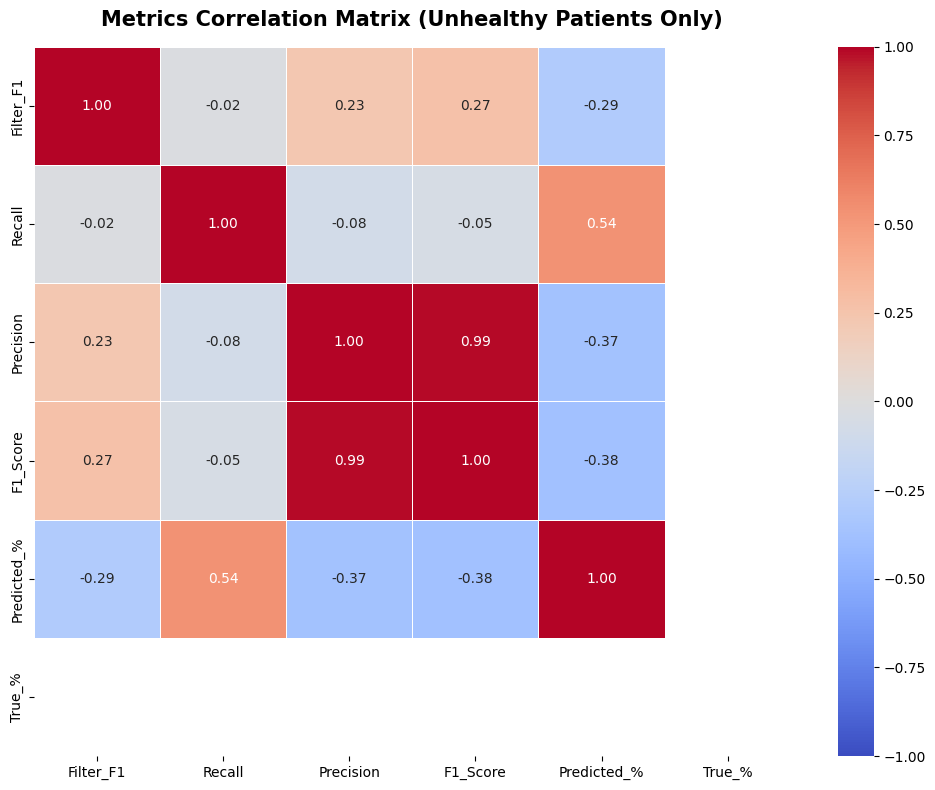

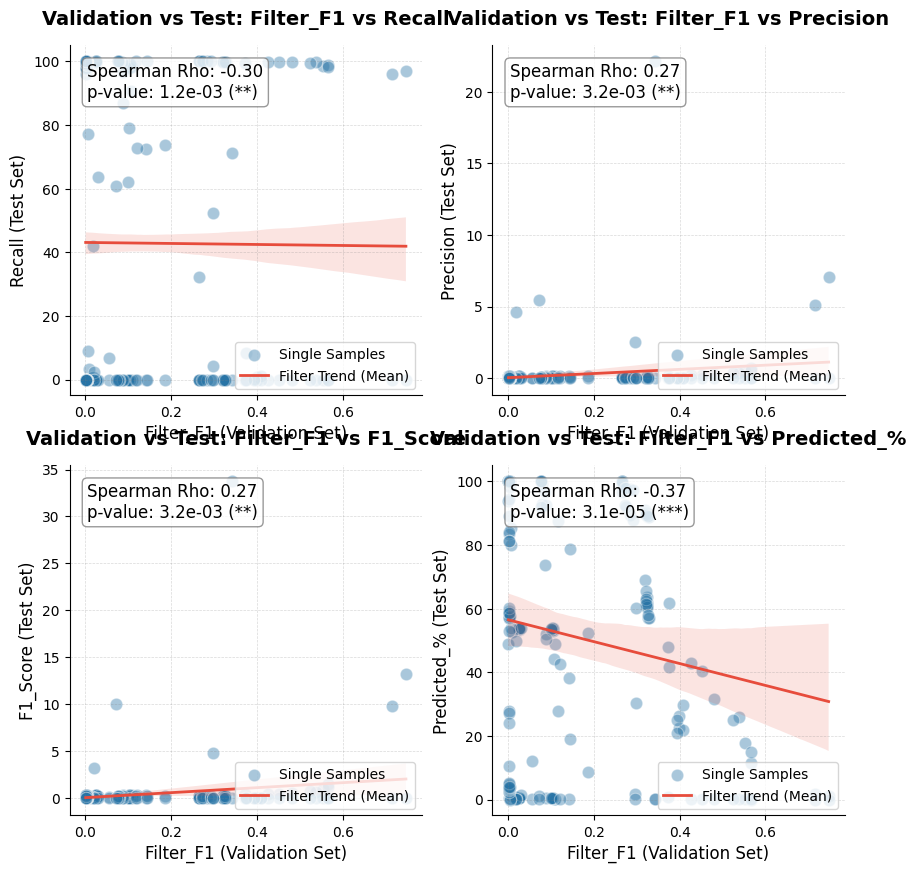

In [22]:

final_scatter_df = add_classification_metrics( pd.DataFrame(single_filters_test_results))

results = PipelineResults(final_scatter_df)

results.show_metrics_correlation_matrix(condition='blast')

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for m, metric in enumerate(['Recall', 'Precision', 'F1_Score', 'Predicted_%']):

    results.show_corr(x='Filter_F1', y=metric, condition=None, axis = axs[m//2, m%2])

display(fig)
plt.close(fig)

In [ ]:
cols = ['filters', 'scalers', 'best_thr', 'max_f1']
all_df = LOPO_df[cols].explode(cols, ignore_index=True)
all_df

single_filters_test_results = []

for i in range(len(all_df)):
    row = all_df.iloc[i]

    temp_metadata_df = pd.DataFrame({
        'filter_weights': [row['filters']],
        'scaler': [row['scalers']]
    })

    test_results = test_phase(
        filter_metadata_df = temp_metadata_df,
        test_pat = test_pat,
        multiple_donations = multiple_donations,
        ALL_DATASETS = ALL_DATASETS,
        max_f1 = row['max_f1'],
        best_thr = row['best_thr'],
        LOPOCV_fold_idx = LOPOCV_fold_idx
    )

    for res_dict in test_results:
        res_dict['Filter_F1'] = row['max_f1']
        single_filters_test_results.append(res_dict)

final_scatter_df = add_classification_metrics( pd.DataFrame(single_filters_test_results))


save = False
if save:

    print(plotdir)
    final_scatter_df.to_csv(os.path.join(plotdir, 'final_scatter.csv'), index = False)

In [ ]:

results = PipelineResults(final_scatter_df)

results.show_metrics_correlation_matrix(condition='blast')

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for m, metric in enumerate(['Recall', 'Precision', 'F1_Score', 'Predicted_%']):

    results.show_corr(x='Filter_F1', y=metric, condition=None, axis = axs[m//2, m%2])

display(fig)
plt.close(fig)

### Ensemble Filter Analysis